Speech: 24000 samples, fs=8000 Hz
  sigma_x=0.2822, excess kurtosis=1.46 (Gaussian=0, Laplace≈3)
Computing theoretical bounds (grouped array)...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2900\2023497946.py:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fx_kde = lambda x: float(kde(x))


  Gaussian f_x: σ*=0.1494, MSE=0.00462, SNR=12.36 dB
  KDE f_x:      σ*=0.1446, MSE=0.00504, SNR=11.99 dB

Running 20 Monte Carlo trials...
  trial 1/20
  trial 6/20
  trial 11/20
  trial 16/20

Method                              sigma_ss     MSE_ss  SNR(dB)
-----------------------------------------------------------------
Theory (Gaussian f_x)                 0.1494    0.00462    12.36
Theory (KDE f_x)                      0.1446    0.00504    11.99
Grouped EKF-SSR (proposed)            0.2023    0.00729    10.39
Grouped fixed sigma=sigma^o           0.1494    0.00647    10.91
Grouped fixed sigma=1.0               1.0000    0.03252     3.90

EKF-SSR vs fixed 1.0 : +6.49 dB
EKF-SSR vs oracle    :  -0.52 dB
Steady weights: w1=0.2815, w2=0.2818


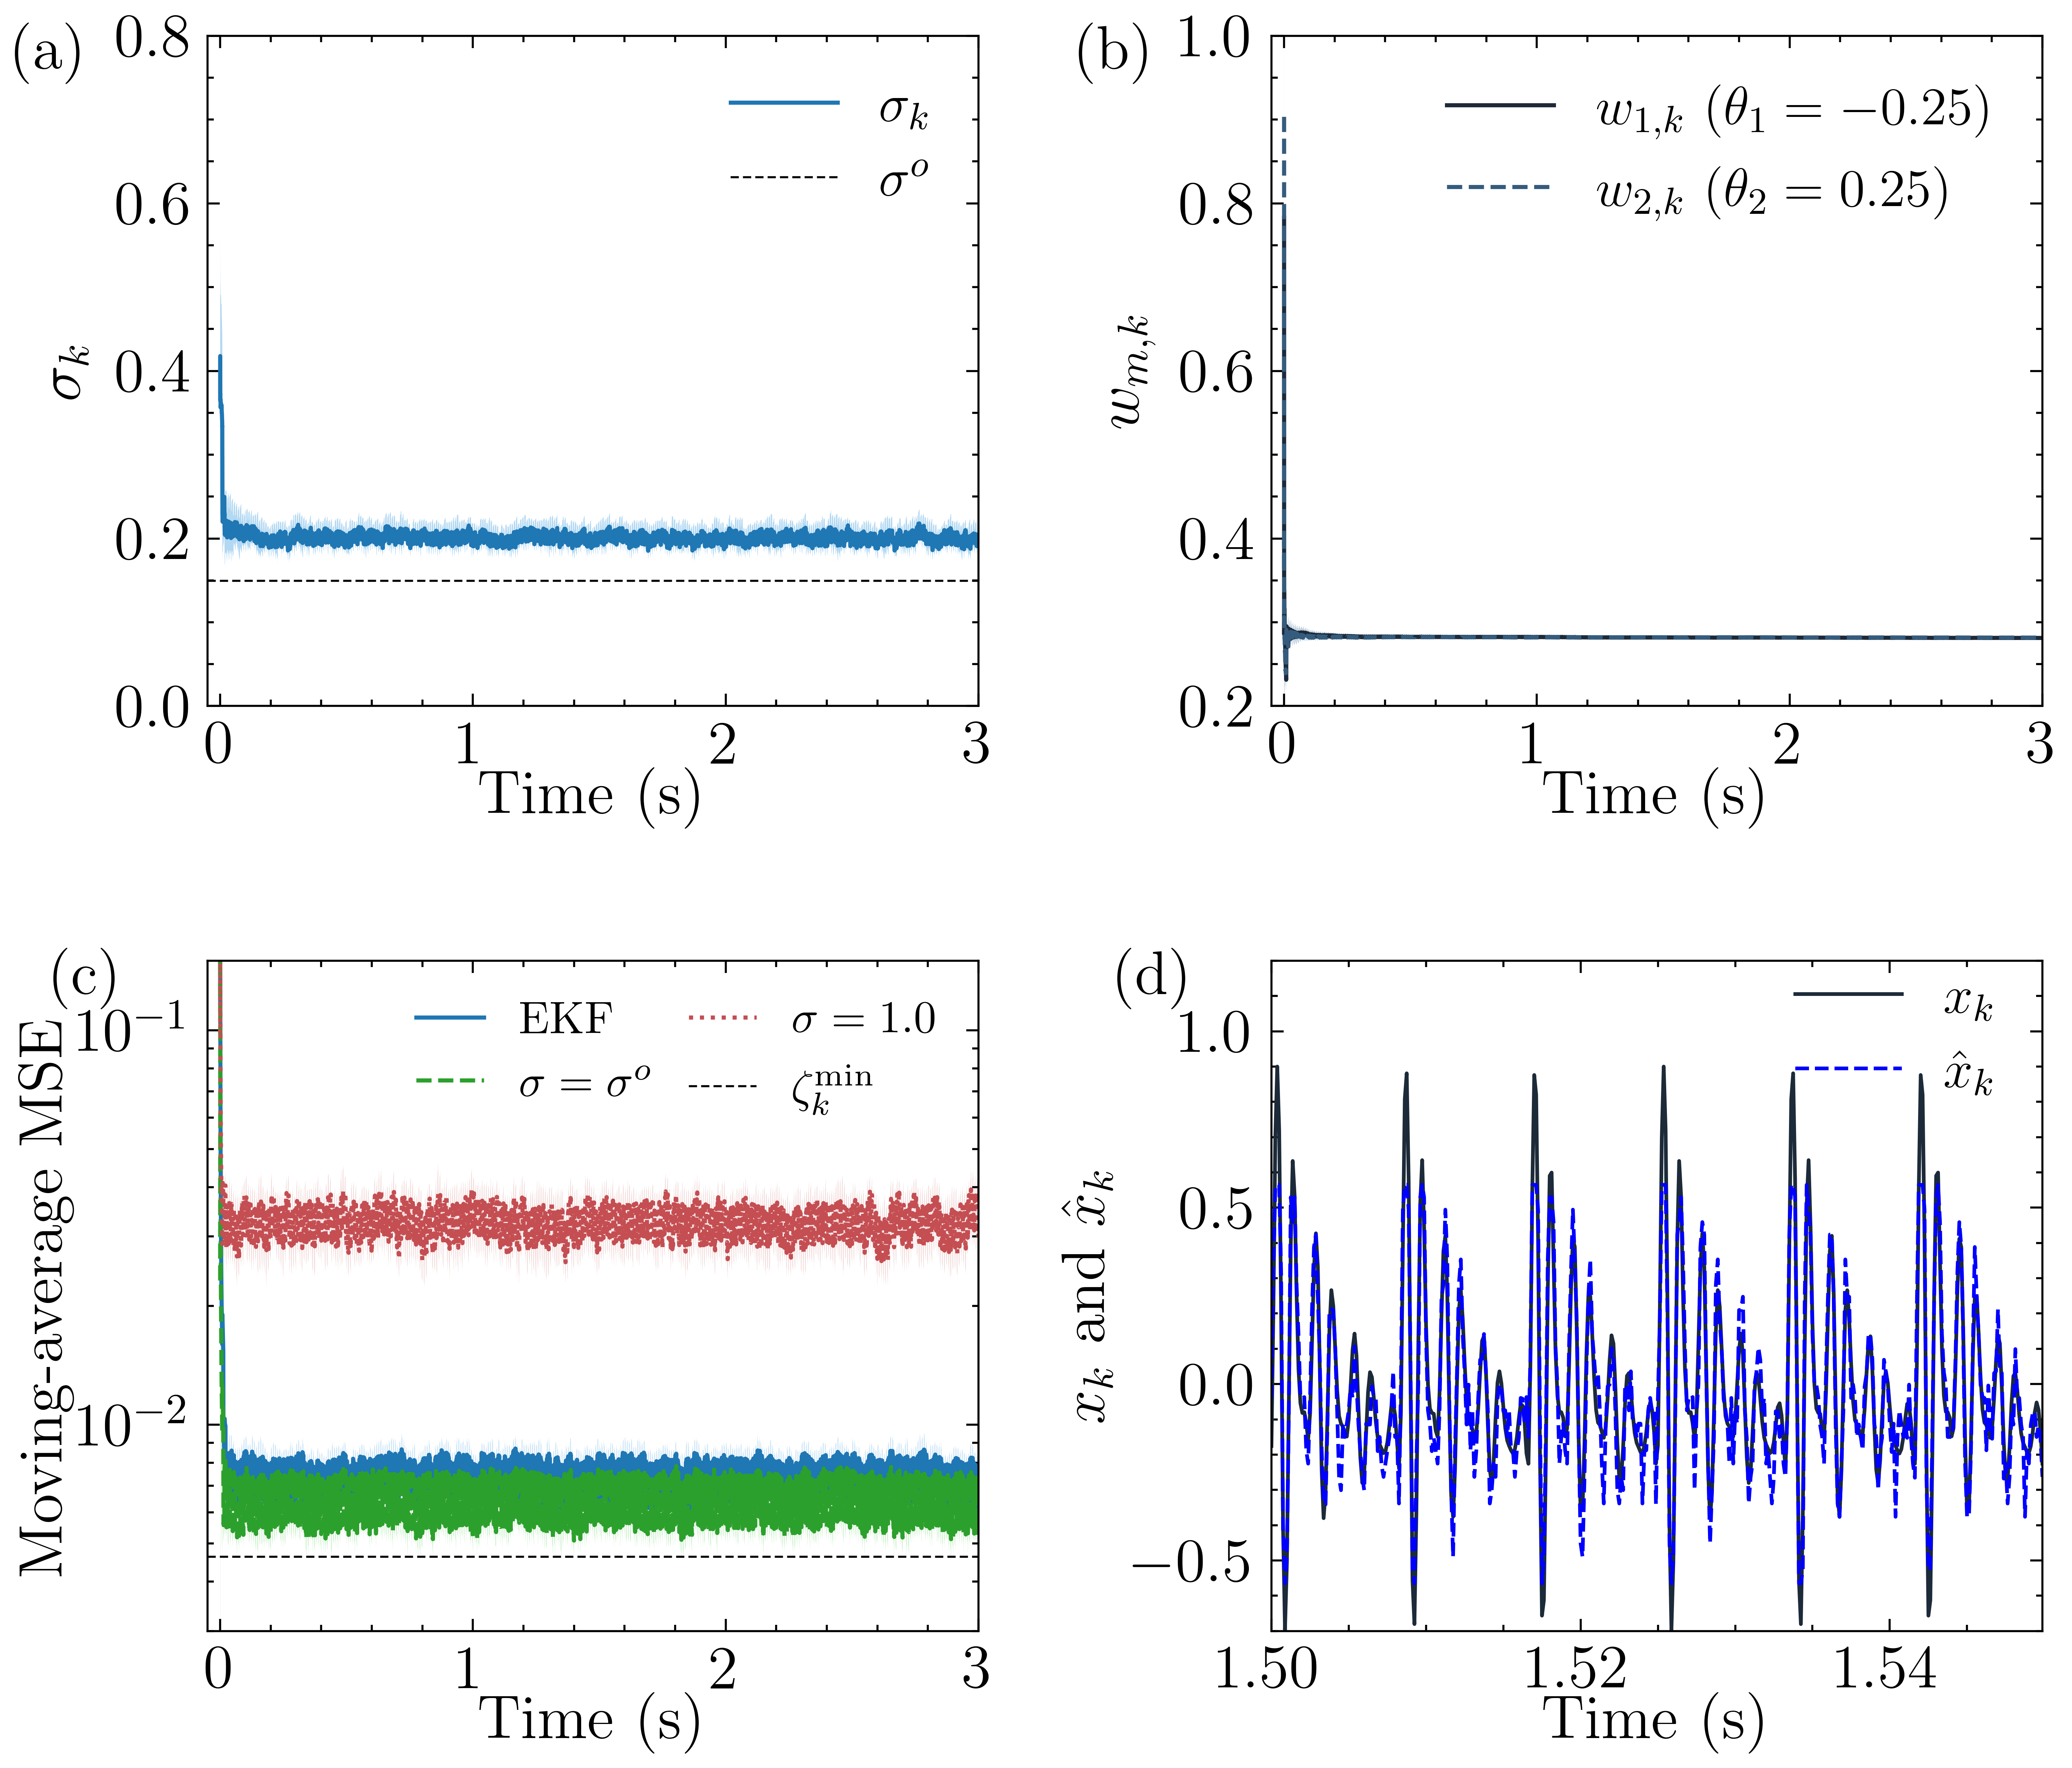


Grouped SSR (N1=15,θ1=-0.25, N2=16,θ2=0.25), 20 trials, speech /a/, fs=8000 Hz
Method                                sigma        MSE  SNR(dB)
-----------------------------------------------------------------
Theory (Gaussian f_x)                0.1494    0.00462    12.36
Theory (KDE f_x)                     0.1446    0.00504    11.99
Grouped EKF-SSR (proposed)           0.2023    0.00729    10.39
Grouped fixed sigma=sigma^o          0.1494    0.00647    10.91
Grouped fixed sigma=1.0              1.0000    0.03252     3.90
SNR gain (EKF-SSR vs fixed 1.0) : +6.49 dB
SNR gap  (EKF-SSR vs KDE opt)   :  -0.52 dB


In [5]:
"""
PyTorch implementation: Grouped EKF-SSR on voiced speech signal.
For subsection: "Grouped summing array for nonstationary signals"

Array structure (M=2 groups, N=31 total):
  Group 1: N1=15 quantizers, threshold theta1 = -0.5  (fixed)
  Group 2: N2=16 quantizers, threshold theta2 = +0.5  (fixed)

Each group output:
  phi_{m,k} = (1/Nm) * sum_n sign(x_k + sigma_k*xi_n - theta_m)

Reconstruction:
  x_hat_k = w1_k * phi_{1,k} + w2_k * phi_{2,k}

EKF estimates sigma_k online; w1_k, w2_k via 2D RLS.

Comparison:
  (1) Grouped EKF-SSR (proposed, sigma_0=0.5)
  (2) Grouped fixed sigma=sigma* (oracle KDE)
  (3) Single group N=31, theta=0, EKF-SSR (baseline)

Two theoretical bounds: Gaussian f_x and empirical KDE.

Run in Jupyter:  %matplotlib inline  (first cell)
"""

import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.signal import lfilter
from scipy.stats import gaussian_kde
from scipy.special import erf
import scienceplots

# ── 绘图风格 ──────────────────────────────────────────
plt.style.use(['science', 'ieee'])
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 10,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 100,      # Jupyter 显示
    'axes.unicode_minus': False,
})

def lighten_color(color, amount=0.25):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1-amount*(1-c[1]), c[2])

# ════════════════════════════════════════════════════════
# 1.  合成语音信号（元音 /a/，男声 F0=120 Hz）
# ════════════════════════════════════════════════════════
torch.manual_seed(2024)
np.random.seed(2024)

fs       = 8000     # 采样率 Hz
duration = 3.0      # 总时长 s
t_arr    = np.arange(0, duration, 1/fs)
Nx_total = len(t_arr)

# 谐波声源
F0 = 120;  harmonics = 25
voice_src = np.zeros(Nx_total)
for k in range(1, harmonics+1):
    voice_src += (1.0/k) * np.sin(2*np.pi*k*F0*t_arr)

# 共振峰滤波（/a/: F1=800 Hz, F2=1200 Hz, F3=2500 Hz）
def formant_filter(sig, fc, bw):
    r     = np.exp(-np.pi*bw/fs)
    theta = 2*np.pi*fc/fs
    return lfilter([1-r], [1, -2*r*np.cos(theta), r**2], sig)

speech = formant_filter(voice_src, 800,  80)
speech = formant_filter(speech,    1200, 100)
speech = formant_filter(speech,    2500, 150)
speech = speech / np.max(np.abs(speech)) * 0.9   # 归一化

sigma_x = float(np.std(speech))
kurt    = float(np.mean((speech - speech.mean())**4) / sigma_x**4 - 3)
print(f"Speech: {Nx_total} samples, fs={fs} Hz")
print(f"  sigma_x={sigma_x:.4f}, excess kurtosis={kurt:.2f} "
      f"(Gaussian=0, Laplace≈3)")

# ════════════════════════════════════════════════════════
# 2.  分组阵列参数（M=2）
# ════════════════════════════════════════════════════════
#  Group 1: N1=15 quantizers, theta1=-0.5
#  Group 2: N2=16 quantizers, theta2=+0.5
N1, theta1 = 15, -0.25
N2, theta2 = 16, +0.25
N_total    = N1 + N2      # = 31

# h_bar for each group (Gaussian dither):
#   h_bar_m(x, sigma) = E[sign(x + sigma*xi - theta_m)]
#                     = erf((x - theta_m) / (sigma*sqrt(2)))
def h_bar_m(x, sigma, theta):
    return erf((x - theta) / (sigma * np.sqrt(2)))

def h_bar_m_deriv_sigma(x, sigma, theta):
    """d/d_sigma of h_bar_m  =  -2/sqrt(pi) * ((x-theta)/sigma^2)
       * exp(-((x-theta)/sigma)^2 / 2) / sqrt(2)"""
    u = (x - theta) / (sigma * np.sqrt(2))
    return -np.sqrt(2/np.pi) * (x-theta) / sigma**2 * np.exp(-u**2)

# ════════════════════════════════════════════════════════
# 3.  理论最优值（分组阵列，两种 f_x 假设）
# ════════════════════════════════════════════════════════
def compute_theory_grouped(fx_fn, N1, theta1, N2, theta2, sx):
    """
    Grouped array MSE:
      MSE = sigma_x^2 - [p1, p2] R^{-1} [p1, p2]^T
    where R = [[R11, R12],[R12, R22]],
      p_m   = E_x[x * h_bar_m(x, sigma)]
      R_mm  = N_m * E_x[h_bar_m^2]  +  (extra from cross terms)
    For M=2, use the closed-form 2x2 inverse.
    """
    def mse_fn(sigma):
        p1  = quad(lambda x: x*h_bar_m(x,sigma,theta1)*fx_fn(x),
                   -6*sx, 6*sx)[0]
        p2  = quad(lambda x: x*h_bar_m(x,sigma,theta2)*fx_fn(x),
                   -6*sx, 6*sx)[0]
        # within-group auto-correlation
        psi11 = quad(lambda x: h_bar_m(x,sigma,theta1)**2*fx_fn(x),
                     -6*sx, 6*sx)[0]
        psi22 = quad(lambda x: h_bar_m(x,sigma,theta2)**2*fx_fn(x),
                     -6*sx, 6*sx)[0]
        # cross-group correlation
        psi12 = quad(lambda x: h_bar_m(x,sigma,theta1)
                               *h_bar_m(x,sigma,theta2)*fx_fn(x),
                     -6*sx, 6*sx)[0]
        # R matrix elements (identical quantizers within each group)
        R11 = 1 + (N1-1)*psi11   # = N1*(auto) + N1*(N1-1)*(cross within)
        R22 = 1 + (N2-1)*psi22
        R12 = N1*N2*psi12 / (N1*N2)   # cross between groups
        # simplified: treat phi_m = (1/Nm)*sum as having
        # E[phi_m^2] = (1/Nm + (1-1/Nm)*psi_mm)
        # Use direct 2x2 Wiener-Hopf:
        # MSE = sx^2 - [p1,p2] * R_phi^{-1} * [p1,p2]^T
        # R_phi[m,m] = E[phi_m^2] , R_phi[1,2]=E[phi1*phi2]
        Rp11 = 1.0/N1 + (1-1.0/N1)*psi11
        Rp22 = 1.0/N2 + (1-1.0/N2)*psi22
        Rp12 = psi12
        det  = Rp11*Rp22 - Rp12**2
        if abs(det) < 1e-12:
            return sx**2
        inv11 = Rp22/det; inv22 = Rp11/det; inv12 = -Rp12/det
        return sx**2 - (p1**2*inv11 + 2*p1*p2*inv12 + p2**2*inv22)

    res = minimize_scalar(mse_fn, bounds=(0.01, 5*sx), method='bounded')
    return res.x, mse_fn(res.x)

print("Computing theoretical bounds (grouped array)...")
# Gaussian f_x
sx = sigma_x
fx_gauss = lambda x: np.exp(-x**2/(2*sx**2))/np.sqrt(2*np.pi*sx**2)
sigma_th_G, mse_th_G = compute_theory_grouped(
    fx_gauss, N1, theta1, N2, theta2, sx)

# Empirical KDE f_x
kde = gaussian_kde(speech, bw_method='silverman')
fx_kde = lambda x: float(kde(x))
sigma_th_E, mse_th_E = compute_theory_grouped(
    fx_kde, N1, theta1, N2, theta2, sx)

sp_pwr_all = np.mean(speech**2)
snr_th_G = 10*np.log10(sp_pwr_all / mse_th_G)
snr_th_E = 10*np.log10(sp_pwr_all / mse_th_E)
print(f"  Gaussian f_x: σ*={sigma_th_G:.4f}, "
      f"MSE={mse_th_G:.5f}, SNR={snr_th_G:.2f} dB")
print(f"  KDE f_x:      σ*={sigma_th_E:.4f}, "
      f"MSE={mse_th_E:.5f}, SNR={snr_th_E:.2f} dB")

# ════════════════════════════════════════════════════════
# 4.  分组 EKF-SSR（PyTorch 内层循环）
# ════════════════════════════════════════════════════════
Q_sigma   = 1e-3
R_sigma   = 1.0
P0_sigma  = 2.0
delta_rls = 0.1
window    = 100     # ~12 ms

def gauss_pdf_t(u):
    return torch.exp(-0.5*u**2) / (2*torch.pi)**0.5

def run_grouped_ekf_ssr(x_np, sigma_init, seed=2024):
    """
    Grouped EKF-SSR:
      - phi1_k = mean(sign(x_k + sigma*xi - theta1)),  xi ~ N(0,1), size N1
      - phi2_k = mean(sign(x_k + sigma*xi - theta2)),  xi ~ N(0,1), size N2
      - x_hat_k = w1*phi1_k + w2*phi2_k
      - 2D RLS updates w1, w2
      - EKF updates sigma via scalar Jacobian H_k = dE[x_hat]/d_sigma
    """
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    th1 = torch.tensor(theta1, dtype=torch.float32)
    th2 = torch.tensor(theta2, dtype=torch.float32)

    # 2D RLS
    w   = torch.tensor([1.0, 1.0])          # [w1, w2]
    P_w = torch.eye(2) * 10.0               # 2x2 covariance

    sigma_k = torch.tensor(float(sigma_init))
    P_sigma = torch.tensor(float(P0_sigma))

    sigma_hist = np.zeros(T)
    w1_hist    = np.zeros(T)
    w2_hist    = np.zeros(T)
    mse_inst   = np.zeros(T)
    xhat_hist  = np.zeros(T)

    for k in range(T):
        x_k = x_t[k]

        torch.manual_seed(seed + 3*k)
        xi1   = torch.randn(N1)
        xi2   = torch.randn(N2)

        # 分组量化器输出
        phi1  = torch.sign(x_k + sigma_k*xi1 - th1).mean()
        phi2  = torch.sign(x_k + sigma_k*xi2 - th2).mean()
        phi_k = torch.stack([phi1, phi2])    # [2]

        # 重建与误差
        x_hat = torch.dot(w, phi_k)
        e_k   = x_k - x_hat

        # 2D RLS 权重更新
        P_phi  = P_w @ phi_k                 # [2]
        denom  = phi_k @ P_phi + delta_rls
        g_rls  = P_phi / denom               # [2] Kalman gain
        w      = w + g_rls * e_k
        P_w    = P_w - torch.outer(g_rls, P_phi)

        # EKF Jacobian: H_k = d(x_hat)/d(sigma)
        #   = w1 * d(phi1)/d(sigma) + w2 * d(phi2)/d(sigma)
        #   d(phi_m)/d(sigma) ≈ -(x_k - theta_m)/sigma^2 * f_xi(u_m)
        s_safe = sigma_k.clamp(min=0.01)
        u1 = (x_k - th1) / s_safe
        u2 = (x_k - th2) / s_safe
        dh1 = -(x_k - th1) / s_safe**2 * gauss_pdf_t(u1)
        dh2 = -(x_k - th2) / s_safe**2 * gauss_pdf_t(u2)
        H_k = w[0]*dh1 + w[1]*dh2           # scalar

        # EKF sigma 更新
        P_pred  = P_sigma + Q_sigma
        K_sigma = P_pred * H_k / (H_k**2 * P_pred + R_sigma)
        step    = (K_sigma * e_k).clamp(-0.3, 0.3)

        sigma_k = (sigma_k + step).clamp(0.01, 5.0)
        P_sigma = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_k.item()
        w1_hist[k]    = w[0].item()
        w2_hist[k]    = w[1].item()
        mse_inst[k]   = e_k.item()**2
        xhat_hist[k]  = x_hat.item()

    return sigma_hist, w1_hist, w2_hist, mse_inst, xhat_hist


def run_grouped_fixed(x_np, sigma_fixed, seed=2024):
    """Grouped array, fixed sigma, 2D RLS weights."""
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)
    th1 = torch.tensor(theta1, dtype=torch.float32)
    th2 = torch.tensor(theta2, dtype=torch.float32)
    w   = torch.tensor([1.0, 1.0])
    P_w = torch.eye(2) * 10.0
    sf  = torch.tensor(float(sigma_fixed))
    mse_inst  = np.zeros(T)
    xhat_hist = np.zeros(T)
    for k in range(T):
        x_k = x_t[k]
        torch.manual_seed(seed+3*k)
        phi1  = torch.sign(x_k + sf*torch.randn(N1) - th1).mean()
        phi2  = torch.sign(x_k + sf*torch.randn(N2) - th2).mean()
        phi_k = torch.stack([phi1, phi2])
        x_hat = torch.dot(w, phi_k); e_k=x_k-x_hat
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g     = P_phi / denom
        w     = w + g*e_k
        P_w   = P_w - torch.outer(g, P_phi)
        mse_inst[k]  = e_k.item()**2
        xhat_hist[k] = x_hat.item()
    return mse_inst, xhat_hist

# ── 因果滑动平均 ──────────────────────────────────────
def causal_ma(x, win):
    out = np.zeros(len(x))
    cs  = np.cumsum(x)
    for i in range(len(x)):
        out[i] = cs[i]/(i+1) if i<win else (cs[i]-cs[i-win])/win
    return out

# ── Monte Carlo 多次仿真 ──────────────────────────────
num_trials = 20
base_seed  = 451
steady     = Nx_total // 2

all_sig  = np.zeros((num_trials, Nx_total))
all_w1   = np.zeros((num_trials, Nx_total))
all_w2   = np.zeros((num_trials, Nx_total))
all_mekf = np.zeros((num_trials, Nx_total))
all_mfix = np.zeros((num_trials, Nx_total))
all_msub = np.zeros((num_trials, Nx_total))
xhat_ekf_demo = None   # 保存第一个 trial 的重建波形用于子图(d)

print(f"\nRunning {num_trials} Monte Carlo trials...")
for tr in range(num_trials):
    seed_t = base_seed + tr * 17
    if tr % 5 == 0:
        print(f"  trial {tr+1}/{num_trials}")

    sh, w1h, w2h, mse_e, xhat_e = run_grouped_ekf_ssr(
        speech, sigma_init=0.5, seed=seed_t)
    all_sig[tr]  = sh
    all_w1[tr]   = w1h
    all_w2[tr]   = w2h
    all_mekf[tr] = causal_ma(mse_e, window)
    if tr == 0:
        xhat_ekf_demo = xhat_e

    mse_f, _ = run_grouped_fixed(speech, sigma_th_G, seed=seed_t)
    all_mfix[tr] = causal_ma(mse_f, window)

    mse_s, _ = run_grouped_fixed(speech, 1.0, seed=seed_t)
    all_msub[tr] = causal_ma(mse_s, window)

# 均值 / 标准差
sig_mean  = all_sig.mean(0);   sig_std  = all_sig.std(0)
w1_mean   = all_w1.mean(0);    w1_std   = all_w1.std(0)
w2_mean   = all_w2.mean(0);    w2_std   = all_w2.std(0)
mekf_mean = all_mekf.mean(0);  mekf_std = all_mekf.std(0)
mfix_mean = all_mfix.mean(0);  mfix_std = all_mfix.std(0)
msub_mean = all_msub.mean(0);  msub_std = all_msub.std(0)

# 稳态统计
sig_ss     = all_sig[:,  steady:].mean()
w1_ss      = all_w1[:,   steady:].mean()
w2_ss      = all_w2[:,   steady:].mean()
mse_ekf_ss = all_mekf[:, steady:].mean()
mse_fix_ss = all_mfix[:, steady:].mean()
mse_sub_ss = all_msub[:, steady:].mean()

sp_pwr  = np.mean(speech[steady:]**2)
snr_ekf = 10*np.log10(sp_pwr / mse_ekf_ss)
snr_fix = 10*np.log10(sp_pwr / mse_fix_ss)
snr_sub = 10*np.log10(sp_pwr / mse_sub_ss)

print(f"\n{'Method':<35} {'sigma_ss':>8} {'MSE_ss':>10} {'SNR(dB)':>8}")
print("-"*65)
for name, sig, mse, snr in [
    ("Theory (Gaussian f_x)",        sigma_th_G, mse_th_G,    snr_th_G),
    ("Theory (KDE f_x)",             sigma_th_E, mse_th_E,    snr_th_E),
    ("Grouped EKF-SSR (proposed)",   sig_ss,     mse_ekf_ss,  snr_ekf),
    ("Grouped fixed sigma=sigma^o",  sigma_th_G, mse_fix_ss,  snr_fix),
    ("Grouped fixed sigma=1.0",      1.0,        mse_sub_ss,  snr_sub),
]:
    print(f"{name:<35} {sig:>8.4f} {mse:>10.5f} {snr:>8.2f}")
print(f"\nEKF-SSR vs fixed 1.0 : +{snr_ekf-snr_sub:.2f} dB")
print(f"EKF-SSR vs oracle    :  {snr_ekf-snr_fix:+.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}")

# ════════════════════════════════════════════════════════
# 5.  绘图（均值 ± std 阴影，参照 Fig7 风格）
# ════════════════════════════════════════════════════════
from matplotlib.ticker import ScalarFormatter

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size'       : 15,
    'axes.labelsize'  : 15,
    'legend.fontsize' : 13,
})

def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount*(1-c[1]), c[2])

# ── 配色定义 ──────────────────────────────────────────
c_sigma  = '#1f77b4';  lc_sigma = lighten_color(c_sigma, amount=0.30)
c_w1     = '#1c2a39';  lc_w1    = lighten_color(c_w1,    amount=0.22)
c_w2     = '#355c7d';  lc_w2    = lighten_color(c_w2,    amount=0.22)
c_ekf_m  = '#1f77b4';  lc_ekf_m = lighten_color(c_ekf_m, amount=0.20)
c_fix_m  = '#2ca02c';  lc_fix_m = lighten_color(c_fix_m, amount=0.20)
c_sub_m  = '#c44e52';  lc_sub_m = lighten_color(c_sub_m, amount=0.20)
c_clean  = '#1c2a39'

labels_txt = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
plt.subplots_adjust(hspace=0.38, wspace=0.38)
axes = axes.flatten()
t_sec = t_arr

# ── (a) sigma_k：均值 ± std ──────────────────────────
ax = axes[0]
ax.fill_between(t_sec,
                np.maximum(sig_mean - sig_std, 0),
                sig_mean + sig_std,
                color=lc_sigma, edgecolor='none')
ax.plot(t_sec, sig_mean,
        color=c_sigma, lw=1.0, label=r'$\sigma_k$')
ax.axhline(sigma_th_G, color='k', lw=0.5, ls=(0, (4, 2)),
           label=r'$\sigma^o$')
ax.set_xlim([-0.05, duration])
ax.set_ylim([0, 0.8])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$\sigma_k$', labelpad=6)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.25, 1.02, labels_txt[0], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (b) w1_k, w2_k：均值 ± std ───────────────────────
ax = axes[1]
ax.fill_between(t_sec,
                np.maximum(w1_mean - w1_std, 0),
                w1_mean + w1_std,
                color=lc_w1, edgecolor='none')
ax.plot(t_sec, w1_mean,
        color=c_w1, lw=1.0,
        label=rf'$w_{{1,k}}$ ($\theta_1={theta1}$)')
ax.fill_between(t_sec,
                np.maximum(w2_mean - w2_std, 0),
                w2_mean + w2_std,
                color=lc_w2, edgecolor='none')
ax.plot(t_sec, w2_mean,
        color=c_w2, lw=1.0, ls='--',
        label=rf'$w_{{2,k}}$ ($\theta_2={theta2}$)')
ax.set_xlim([-0.05, duration])
ax.set_ylim([0.2, 1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$w_{m,k}$', labelpad=6)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.25, 1.02, labels_txt[1], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (c) 滑动平均 MSE：均值 ± std，log 轴 ─────────────
ax = axes[2]
ax.fill_between(t_sec,
                np.maximum(mekf_mean - mekf_std, 1e-5),
                mekf_mean + mekf_std,
                color=lc_ekf_m, edgecolor='none')
ax.plot(t_sec, mekf_mean,
        color=c_ekf_m, lw=1.0, label='EKF')

ax.fill_between(t_sec,
                np.maximum(mfix_mean - mfix_std, 1e-5),
                mfix_mean + mfix_std,
                color=lc_fix_m, edgecolor='none')
ax.plot(t_sec, mfix_mean,
        color=c_fix_m, lw=1.0, ls='--',
        label=r'$\sigma = \sigma^o$')

ax.fill_between(t_sec,
                np.maximum(msub_mean - msub_std, 1e-5),
                msub_mean + msub_std,
                color=lc_sub_m, edgecolor='none')
ax.plot(t_sec, msub_mean,
        color=c_sub_m, lw=1.0, ls=':',
        label=r'$\sigma = 1.0$')

ax.axhline(mse_th_G, color='k', lw=0.5, ls=(0, (4, 2)),
           label=r'$\zeta^{\rm min}_k$')
ax.set_yscale('log')
ax.set_xlim([-0.05, duration])
ax.set_ylim([3e-3, 1.5e-1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'Moving-average MSE', labelpad=1)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9,
          ncol=2, columnspacing=0.8, handlelength=1.5)
ax.text(-0.2, 1.02, labels_txt[2], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (d) 50 ms 波形重建（trial 1，稳态段）─────────────
ax = axes[3]
k0 = steady
k1 = k0 + int(0.05 * fs)
t_show = t_sec[k0:k1]
ax.plot(t_show, speech[k0:k1],
        color=c_clean, lw=0.9, label=r'$x_k$')
ax.plot(t_show, xhat_ekf_demo[k0:k1],
        color='blue', lw=0.9, ls='--', label=r'$\hat{x}_k$')
ax.set_ylim([-0.7, 1.2])
ax.set_xlim([t_show[0], t_show[-1]])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$', labelpad=4)
ax.legend(loc='upper right',
          bbox_to_anchor=(1, 1.05),
          fontsize=13, framealpha=0.9)
ax.text(-0.2, 1.02, labels_txt[3], transform=ax.transAxes,
        fontsize=15, va='top')

fig.savefig('D:/IEEE 2025 Adaptive weighted SSR/Figspeech.eps',
            format='eps', dpi=800, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════
# 6.  稳态汇总表
# ════════════════════════════════════════════════════════
print("\n" + "="*65)
print(f"Grouped SSR (N1={N1},θ1={theta1}, N2={N2},θ2={theta2}), "
      f"{num_trials} trials, speech /a/, fs={fs} Hz")
print("="*65)
print(f"{'Method':<35} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*65)
for name, sig, mse, snr in [
    ("Theory (Gaussian f_x)",        sigma_th_G, mse_th_G,   snr_th_G),
    ("Theory (KDE f_x)",             sigma_th_E, mse_th_E,   snr_th_E),
    ("Grouped EKF-SSR (proposed)",   sig_ss,     mse_ekf_ss, snr_ekf),
    ("Grouped fixed sigma=sigma^o",  sigma_th_G, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",      1.0,        mse_sub_ss, snr_sub),
]:
    print(f"{name:<35} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print("="*65)
print(f"SNR gain (EKF-SSR vs fixed 1.0) : +{snr_ekf-snr_sub:.2f} dB")
print(f"SNR gap  (EKF-SSR vs KDE opt)   :  {snr_ekf-snr_fix:+.2f} dB")

Speech: 24000 samples, fs=8000 Hz
  sigma_x=0.2822, excess kurtosis=1.46 (Gaussian=0, Laplace≈3)

Array configuration (N_total=31):
  Group 1: N1=10, theta1=-0.25
  Group 2: N2=11, theta2=0.0
  Group 3: N3=10, theta3=0.25

Computing theoretical bounds (3-group array)...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\2982122929.py:144: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fx_kde  = lambda x: float(kde(x))


  Gaussian f_x: σ*=0.0971, MSE=0.00478, SNR=12.21 dB
  KDE f_x:      σ*=0.1013, MSE=0.00579, SNR=11.39 dB

Running 20 Monte Carlo trials...
  trial 1/20
  trial 6/20
  trial 11/20
  trial 16/20

Method                                 sigma        MSE  SNR(dB)
-----------------------------------------------------------------
Theory (Gaussian f_x)                 0.0971    0.00478    12.21
Theory (KDE f_x)                      0.1013    0.00579    11.39
Grouped EKF-SSR (proposed)            0.2849    0.00982     9.10
Grouped fixed sigma=sigma^o           0.0971    0.00715    10.47
Grouped fixed sigma=1.0               1.0000    0.03244     3.91

EKF-SSR vs fixed 1.0 : +5.19 dB
EKF-SSR vs oracle    :  -1.38 dB
Steady weights: w1=0.2045, w2=0.1500, w3=0.1973


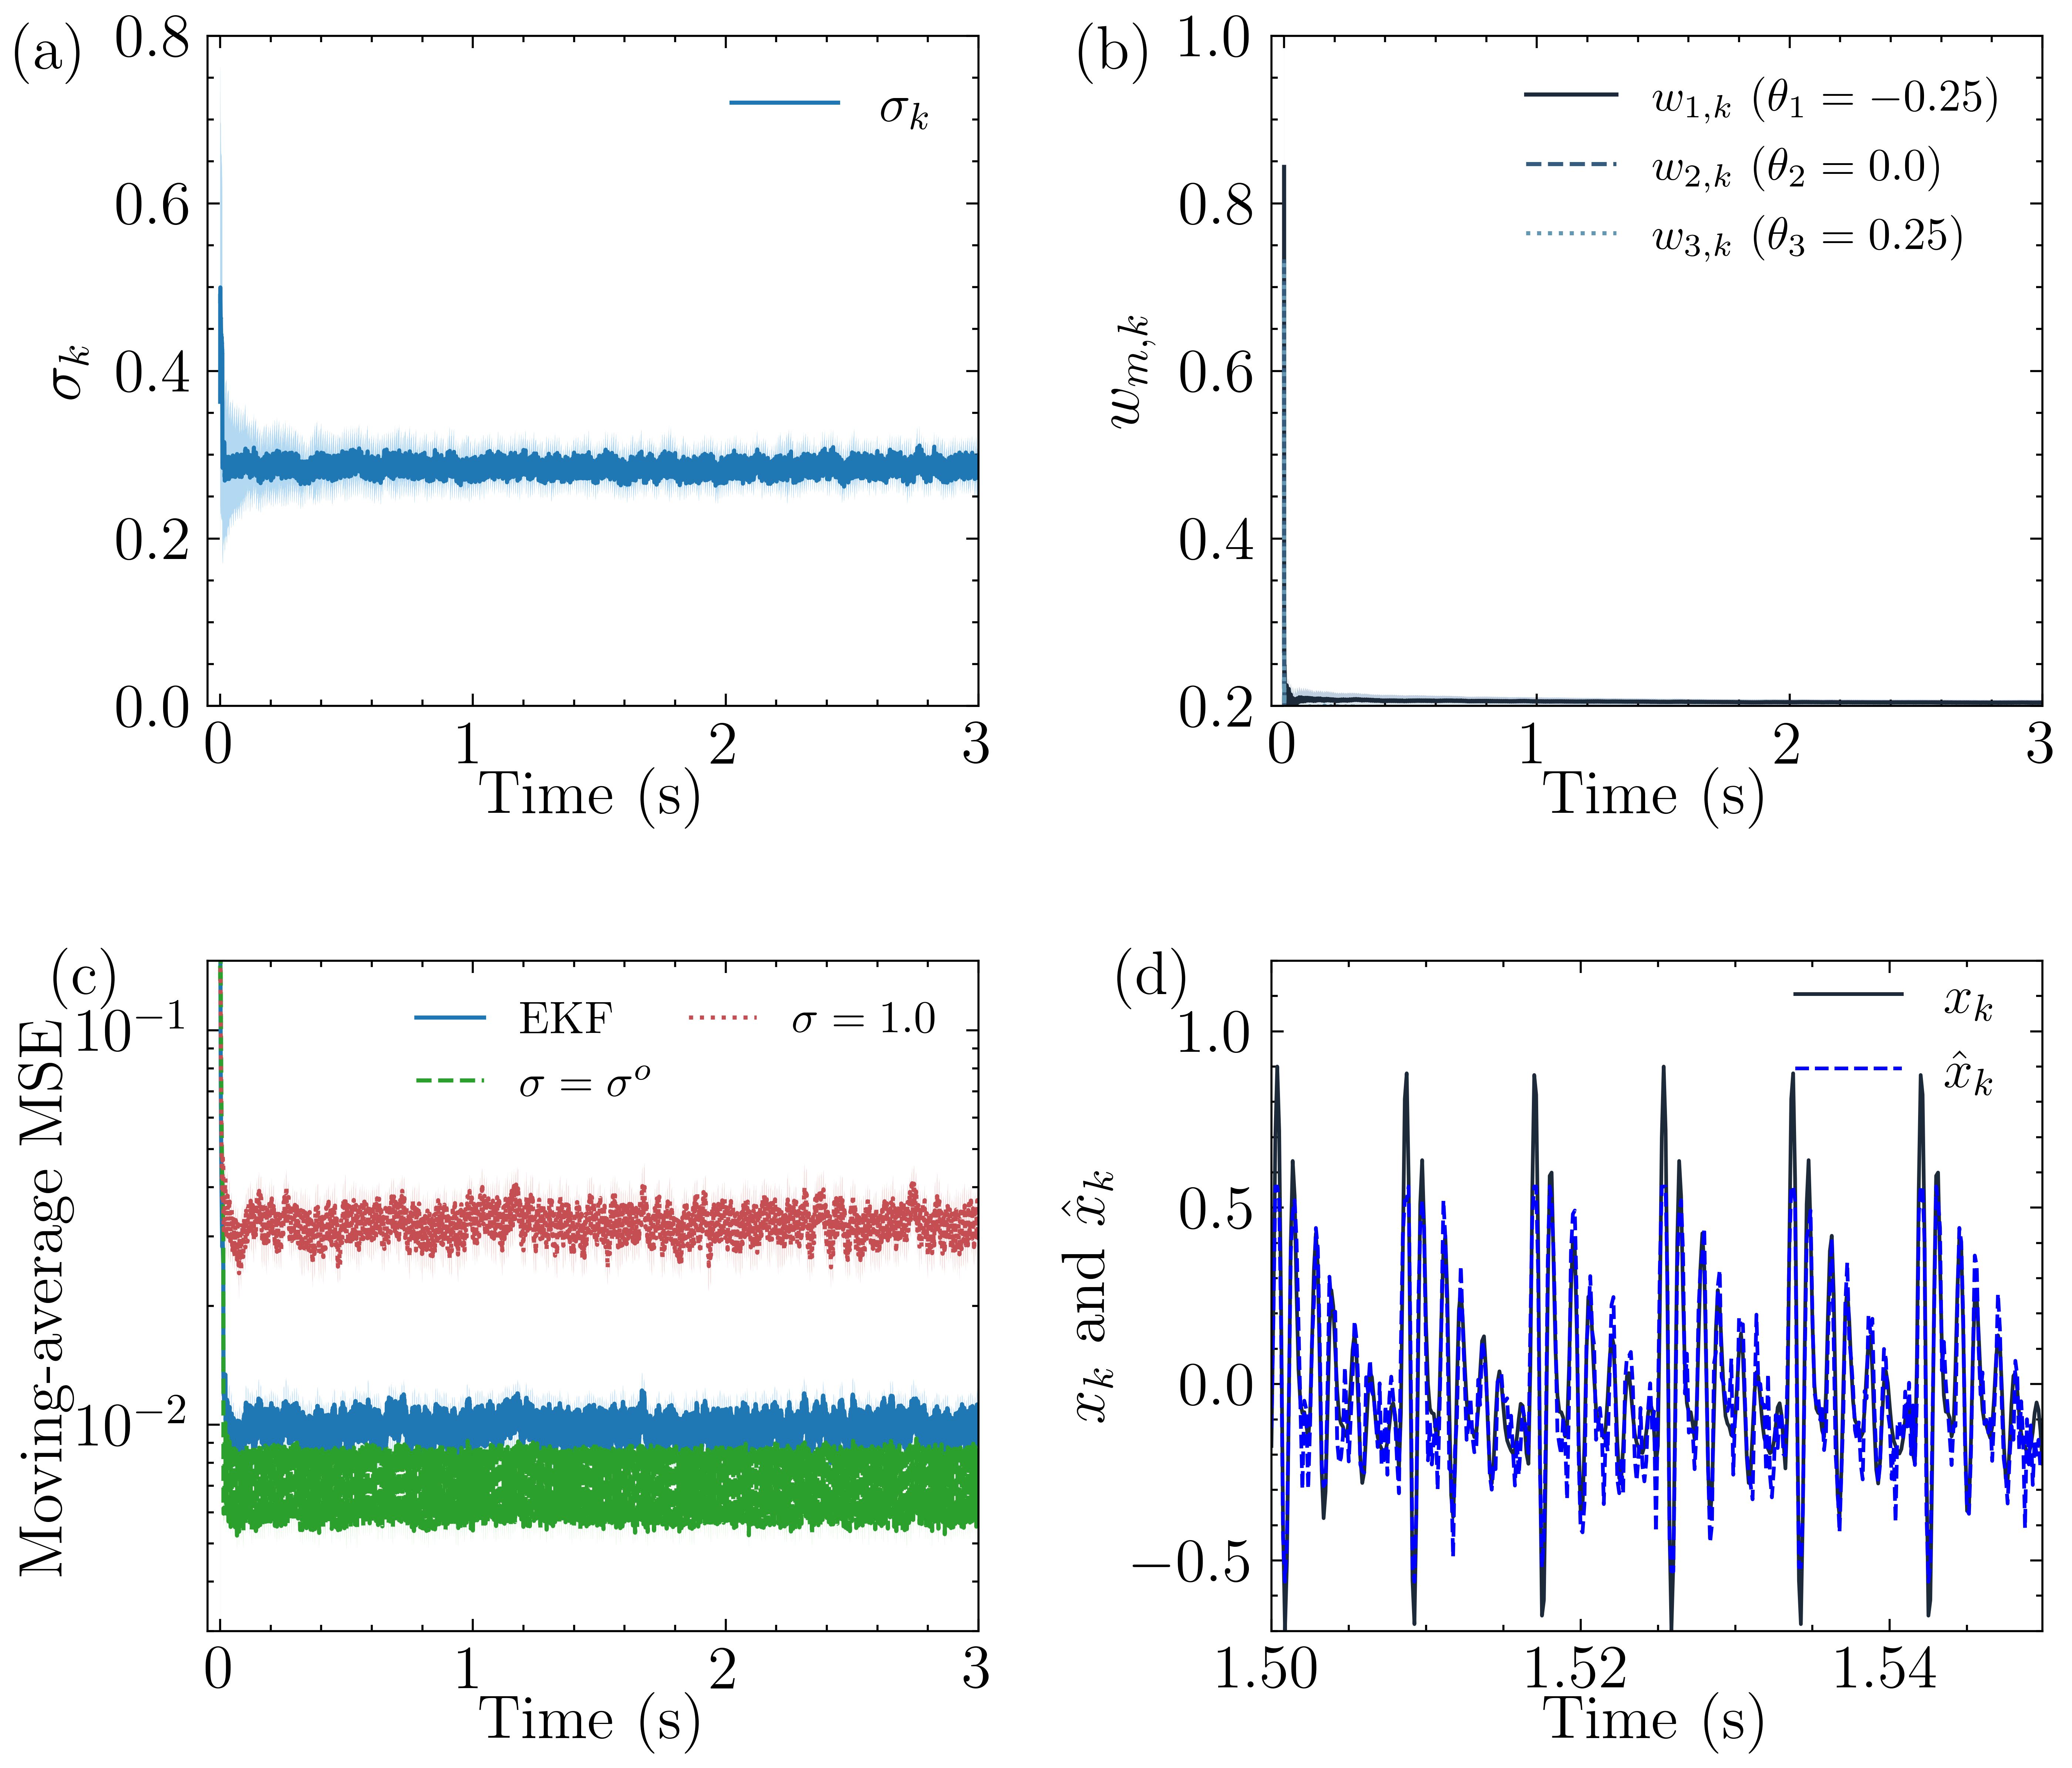


3-Group SSR (N1=10,θ1=-0.25, N2=11,θ2=0.0, N3=10,θ3=0.25)
20 trials, speech /a/, fs=8000 Hz
Method                                sigma        MSE  SNR(dB)
-----------------------------------------------------------------
Theory (Gaussian f_x)                0.0971    0.00478    12.21
Theory (KDE f_x)                     0.1013    0.00579    11.39
Grouped EKF-SSR (proposed)           0.2849    0.00982     9.10
Grouped fixed sigma=sigma^o          0.0971    0.00715    10.47
Grouped fixed sigma=1.0              1.0000    0.03244     3.91
SNR gain (EKF-SSR vs fixed 1.0) : +5.19 dB
SNR gap  (EKF-SSR vs KDE opt)   :  -1.38 dB
Steady weights: w1=0.2045, w2=0.1500, w3=0.1973


In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.signal import lfilter
from scipy.stats import gaussian_kde
from scipy.special import erf
import scienceplots

# ── 绘图风格 ──────────────────────────────────────────
plt.style.use(['science', 'ieee'])
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 10,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 100,
    'axes.unicode_minus': False,
})

def lighten_color(color, amount=0.25):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1-amount*(1-c[1]), c[2])

# ════════════════════════════════════════════════════════
# 1.  合成语音信号（元音 /a/，男声 F0=120 Hz）
# ════════════════════════════════════════════════════════
torch.manual_seed(2024)
np.random.seed(2024)

fs       = 8000
duration = 3.0
t_arr    = np.arange(0, duration, 1/fs)
Nx_total = len(t_arr)

F0 = 120;  harmonics = 25
voice_src = np.zeros(Nx_total)
for k in range(1, harmonics+1):
    voice_src += (1.0/k) * np.sin(2*np.pi*k*F0*t_arr)

def formant_filter(sig, fc, bw):
    r     = np.exp(-np.pi*bw/fs)
    theta = 2*np.pi*fc/fs
    return lfilter([1-r], [1, -2*r*np.cos(theta), r**2], sig)

speech = formant_filter(voice_src, 800,  80)
speech = formant_filter(speech,    1200, 100)
speech = formant_filter(speech,    2500, 150)
speech = speech / np.max(np.abs(speech)) * 0.9

sigma_x = float(np.std(speech))
kurt    = float(np.mean((speech - speech.mean())**4) / sigma_x**4 - 3)
print(f"Speech: {Nx_total} samples, fs={fs} Hz")
print(f"  sigma_x={sigma_x:.4f}, excess kurtosis={kurt:.2f} "
      f"(Gaussian=0, Laplace≈3)")

# ════════════════════════════════════════════════════════
# 2.  三组阵列参数
#     Group 1: N1=10, theta1=-0.25
#     Group 2: N2=11, theta2= 0.00
#     Group 3: N3=10, theta3=+0.25
# ════════════════════════════════════════════════════════
N1, theta1 = 10, -0.28
N2, theta2 = 11,  0.00
N3, theta3 = 10, +0.28
N_total    = N1 + N2 + N3      # = 31

print(f"\nArray configuration (N_total={N_total}):")
print(f"  Group 1: N1={N1}, theta1={theta1}")
print(f"  Group 2: N2={N2}, theta2={theta2}")
print(f"  Group 3: N3={N3}, theta3={theta3}")

# ════════════════════════════════════════════════════════
# 3.  辅助函数
# ════════════════════════════════════════════════════════
def h_bar_m(x, sigma, theta):
    return erf((x - theta) / (sigma * np.sqrt(2)))

# ════════════════════════════════════════════════════════
# 4.  三组阵列理论最优值（3×3 Wiener-Hopf）
# ════════════════════════════════════════════════════════
def compute_theory_3group(fx_fn, N1, theta1, N2, theta2, N3, theta3, sx):
    """
    3-group Wiener-Hopf:
      MSE = sx^2 - p^T R_phi^{-1} p
    where p = [p1, p2, p3], R_phi is 3x3.
    """
    def mse_fn(sigma):
        p = np.zeros(3)
        thetas = [theta1, theta2, theta3]
        for i, th in enumerate(thetas):
            p[i] = quad(lambda x: x * h_bar_m(x, sigma, th) * fx_fn(x),
                        -6*sx, 6*sx)[0]

        # psi_ij = E[h_bar_i * h_bar_j]
        psi = np.zeros((3, 3))
        for i, thi in enumerate(thetas):
            for j, thj in enumerate(thetas):
                if j < i:
                    psi[i, j] = psi[j, i]
                else:
                    psi[i, j] = quad(
                        lambda x: h_bar_m(x, sigma, thi)
                                  * h_bar_m(x, sigma, thj) * fx_fn(x),
                        -6*sx, 6*sx)[0]

        # R_phi[m,m] = 1/Nm + (1 - 1/Nm)*psi_mm
        # R_phi[m,n] = psi_mn  (m != n)
        Ns = [N1, N2, N3]
        R  = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                if i == j:
                    R[i, j] = 1.0/Ns[i] + (1 - 1.0/Ns[i]) * psi[i, i]
                else:
                    R[i, j] = psi[i, j]

        try:
            Rinv = np.linalg.inv(R)
        except np.linalg.LinAlgError:
            return sx**2
        return sx**2 - p @ Rinv @ p

    res = minimize_scalar(mse_fn, bounds=(0.01, 5*sx), method='bounded')
    return res.x, mse_fn(res.x)

print("\nComputing theoretical bounds (3-group array)...")
sx = sigma_x

# Gaussian f_x
fx_gauss = lambda x: np.exp(-x**2/(2*sx**2)) / np.sqrt(2*np.pi*sx**2)
sigma_th_G, mse_th_G = compute_theory_3group(
    fx_gauss, N1, theta1, N2, theta2, N3, theta3, sx)

# KDE f_x
kde     = gaussian_kde(speech, bw_method='silverman')
fx_kde  = lambda x: float(kde(x))
sigma_th_E, mse_th_E = compute_theory_3group(
    fx_kde, N1, theta1, N2, theta2, N3, theta3, sx)

sp_pwr_all = np.mean(speech**2)
snr_th_G   = 10*np.log10(sp_pwr_all / mse_th_G)
snr_th_E   = 10*np.log10(sp_pwr_all / mse_th_E)
print(f"  Gaussian f_x: σ*={sigma_th_G:.4f}, "
      f"MSE={mse_th_G:.5f}, SNR={snr_th_G:.2f} dB")
print(f"  KDE f_x:      σ*={sigma_th_E:.4f}, "
      f"MSE={mse_th_E:.5f}, SNR={snr_th_E:.2f} dB")

# ════════════════════════════════════════════════════════
# 5.  三组 EKF-SSR（PyTorch）
# ════════════════════════════════════════════════════════
Q_sigma   = 1e-3
R_sigma   = 1.0
P0_sigma  = 2.0
delta_rls = 0.1
window    = 100

def gauss_pdf_t(u):
    return torch.exp(-0.5*u**2) / (2*torch.pi)**0.5

def run_grouped_ekf_ssr(x_np, sigma_init, seed=2024):
    """
    3-group EKF-SSR:
      phi_m = mean(sign(x + sigma*xi - theta_m)), m=1,2,3
      x_hat = w1*phi1 + w2*phi2 + w3*phi3
      3D RLS updates [w1,w2,w3]
      EKF updates sigma via scalar Jacobian H_k = sum_m w_m * d(phi_m)/d(sigma)
    """
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))

    # 3D RLS
    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0

    sigma_k = torch.tensor(float(sigma_init))
    P_sigma = torch.tensor(float(P0_sigma))

    sigma_hist = np.zeros(T)
    w1_hist    = np.zeros(T)
    w2_hist    = np.zeros(T)
    w3_hist    = np.zeros(T)
    mse_inst   = np.zeros(T)
    xhat_hist  = np.zeros(T)

    for k in range(T):
        x_k = x_t[k]

        # 三组量化器输出
        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sigma_k*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sigma_k*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sigma_k*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])   # [3]

        # 重建与误差
        x_hat = torch.dot(w, phi_k)
        e_k   = x_k - x_hat

        # 3D RLS 权重更新
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g_rls = P_phi / denom
        w     = w + g_rls * e_k
        P_w   = P_w - torch.outer(g_rls, P_phi)

        # EKF Jacobian: H_k = sum_m w_m * d(phi_m)/d(sigma)
        s_safe = sigma_k.clamp(min=0.01)
        u1 = (x_k - th1) / s_safe
        u2 = (x_k - th2) / s_safe
        u3 = (x_k - th3) / s_safe
        dh1 = -(x_k - th1) / s_safe**2 * gauss_pdf_t(u1)
        dh2 = -(x_k - th2) / s_safe**2 * gauss_pdf_t(u2)
        dh3 = -(x_k - th3) / s_safe**2 * gauss_pdf_t(u3)
        H_k = w[0]*dh1 + w[1]*dh2 + w[2]*dh3

        # EKF sigma 更新
        P_pred  = P_sigma + Q_sigma
        K_sigma = P_pred * H_k / (H_k**2 * P_pred + R_sigma)
        step    = (K_sigma * e_k).clamp(-0.3, 0.3)
        sigma_k = (sigma_k + step).clamp(0.01, 5.0)
        P_sigma = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_k.item()
        w1_hist[k]    = w[0].item()
        w2_hist[k]    = w[1].item()
        w3_hist[k]    = w[2].item()
        mse_inst[k]   = e_k.item()**2
        xhat_hist[k]  = x_hat.item()

    return sigma_hist, w1_hist, w2_hist, w3_hist, mse_inst, xhat_hist


def run_grouped_fixed(x_np, sigma_fixed, seed=2024):
    """3-group array, fixed sigma, 3D RLS weights."""
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)
    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))
    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0
    sf  = torch.tensor(float(sigma_fixed))
    mse_inst  = np.zeros(T)
    xhat_hist = np.zeros(T)
    for k in range(T):
        x_k = x_t[k]
        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sf*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sf*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sf*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])
        x_hat = torch.dot(w, phi_k); e_k = x_k - x_hat
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g     = P_phi / denom
        w     = w + g*e_k
        P_w   = P_w - torch.outer(g, P_phi)
        mse_inst[k]  = e_k.item()**2
        xhat_hist[k] = x_hat.item()
    return mse_inst, xhat_hist

# ── 因果滑动平均 ──────────────────────────────────────
def causal_ma(x, win):
    out = np.zeros(len(x))
    cs  = np.cumsum(x)
    for i in range(len(x)):
        out[i] = cs[i]/(i+1) if i < win else (cs[i]-cs[i-win])/win
    return out

# ── Monte Carlo ───────────────────────────────────────
num_trials = 20
base_seed  = 451
steady     = Nx_total // 2

all_sig  = np.zeros((num_trials, Nx_total))
all_w1   = np.zeros((num_trials, Nx_total))
all_w2   = np.zeros((num_trials, Nx_total))
all_w3   = np.zeros((num_trials, Nx_total))
all_mekf = np.zeros((num_trials, Nx_total))
all_mfix = np.zeros((num_trials, Nx_total))
all_msub = np.zeros((num_trials, Nx_total))
xhat_ekf_demo = None

print(f"\nRunning {num_trials} Monte Carlo trials...")
for tr in range(num_trials):
    seed_t = base_seed + tr * 17
    if tr % 5 == 0:
        print(f"  trial {tr+1}/{num_trials}")

    sh, w1h, w2h, w3h, mse_e, xhat_e = run_grouped_ekf_ssr(
        speech, sigma_init=0.5, seed=seed_t)
    all_sig[tr]  = sh
    all_w1[tr]   = w1h
    all_w2[tr]   = w2h
    all_w3[tr]   = w3h
    all_mekf[tr] = causal_ma(mse_e, window)
    if tr == 0:
        xhat_ekf_demo = xhat_e

    mse_f, _ = run_grouped_fixed(speech, sigma_th_G, seed=seed_t)
    all_mfix[tr] = causal_ma(mse_f, window)

    mse_s, _ = run_grouped_fixed(speech, 1.0, seed=seed_t)
    all_msub[tr] = causal_ma(mse_s, window)

# 均值 / 标准差
sig_mean  = all_sig.mean(0);   sig_std  = all_sig.std(0)
w1_mean   = all_w1.mean(0);    w1_std   = all_w1.std(0)
w2_mean   = all_w2.mean(0);    w2_std   = all_w2.std(0)
w3_mean   = all_w3.mean(0);    w3_std   = all_w3.std(0)
mekf_mean = all_mekf.mean(0);  mekf_std = all_mekf.std(0)
mfix_mean = all_mfix.mean(0);  mfix_std = all_mfix.std(0)
msub_mean = all_msub.mean(0);  msub_std = all_msub.std(0)

sp_pwr      = np.mean(speech[steady:]**2)
mse_ekf_ss  = all_mekf[:, steady:].mean()
mse_fix_ss  = all_mfix[:, steady:].mean()
mse_sub_ss  = all_msub[:, steady:].mean()
sig_ss      = all_sig[:,  steady:].mean()
w1_ss       = all_w1[:,   steady:].mean()
w2_ss       = all_w2[:,   steady:].mean()
w3_ss       = all_w3[:,   steady:].mean()
snr_ekf     = 10*np.log10(sp_pwr / mse_ekf_ss)
snr_fix     = 10*np.log10(sp_pwr / mse_fix_ss)
snr_sub     = 10*np.log10(sp_pwr / mse_sub_ss)

print(f"\n{'Method':<35} {'sigma':>8} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*65)
for name, sig, mse, snr in [
    ("Theory (Gaussian f_x)",        sigma_th_G, mse_th_G,   snr_th_G),
    ("Theory (KDE f_x)",             sigma_th_E, mse_th_E,   snr_th_E),
    ("Grouped EKF-SSR (proposed)",   sig_ss,     mse_ekf_ss, snr_ekf),
    ("Grouped fixed sigma=sigma^o",  sigma_th_G, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",      1.0,        mse_sub_ss, snr_sub),
]:
    print(f"{name:<35} {sig:>8.4f} {mse:>10.5f} {snr:>8.2f}")
print(f"\nEKF-SSR vs fixed 1.0 : +{snr_ekf-snr_sub:.2f} dB")
print(f"EKF-SSR vs oracle    :  {snr_ekf-snr_fix:+.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

# ════════════════════════════════════════════════════════
# 6.  绘图（均值 ± std 阴影）
# ════════════════════════════════════════════════════════
from matplotlib.ticker import ScalarFormatter

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size'       : 15,
    'axes.labelsize'  : 15,
    'legend.fontsize' : 13,
})

def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount*(1-c[1]), c[2])

c_sigma  = '#1f77b4';  lc_sigma = lighten_color(c_sigma, amount=0.30)
c_w1     = '#1c2a39';  lc_w1    = lighten_color(c_w1,    amount=0.22)
c_w2     = '#355c7d';  lc_w2    = lighten_color(c_w2,    amount=0.22)
c_w3     = '#6497b1';  lc_w3    = lighten_color(c_w3,    amount=0.22)
c_ekf_m  = '#1f77b4';  lc_ekf_m = lighten_color(c_ekf_m, amount=0.20)
c_fix_m  = '#2ca02c';  lc_fix_m = lighten_color(c_fix_m, amount=0.20)
c_sub_m  = '#c44e52';  lc_sub_m = lighten_color(c_sub_m, amount=0.20)
c_clean  = '#1c2a39'

labels_txt = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
plt.subplots_adjust(hspace=0.38, wspace=0.38)
axes = axes.flatten()
t_sec = t_arr

# ── (a) sigma_k ───────────────────────────────────────
ax = axes[0]
ax.fill_between(t_sec,
                np.maximum(sig_mean - sig_std, 0),
                sig_mean + sig_std,
                color=lc_sigma, edgecolor='none')
ax.plot(t_sec, sig_mean, color=c_sigma, lw=1.0, label=r'$\sigma_k$')
ax.set_xlim([-0.05, duration])
ax.set_ylim([0, 0.8])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$\sigma_k$', labelpad=6)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.25, 1.02, labels_txt[0], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (b) w1_k, w2_k, w3_k ─────────────────────────────
ax = axes[1]
ax.fill_between(t_sec,
                np.maximum(w1_mean - w1_std, 0),
                w1_mean + w1_std,
                color=lc_w1, edgecolor='none')
ax.plot(t_sec, w1_mean, color=c_w1, lw=1.0,
        label=rf'$w_{{1,k}}$ ($\theta_1={theta1}$)')
ax.fill_between(t_sec,
                np.maximum(w2_mean - w2_std, 0),
                w2_mean + w2_std,
                color=lc_w2, edgecolor='none')
ax.plot(t_sec, w2_mean, color=c_w2, lw=1.0, ls='--',
        label=rf'$w_{{2,k}}$ ($\theta_2={theta2}$)')
ax.fill_between(t_sec,
                np.maximum(w3_mean - w3_std, 0),
                w3_mean + w3_std,
                color=lc_w3, edgecolor='none')
ax.plot(t_sec, w3_mean, color=c_w3, lw=1.0, ls=':',
        label=rf'$w_{{3,k}}$ ($\theta_3={theta3}$)')
ax.set_xlim([-0.05, duration])
ax.set_ylim([0.2, 1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$w_{m,k}$', labelpad=6)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.text(-0.25, 1.02, labels_txt[1], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (c) 滑动平均 MSE（log轴，无sigma^o参考线）─────────
ax = axes[2]
ax.fill_between(t_sec,
                np.maximum(mekf_mean - mekf_std, 1e-5),
                mekf_mean + mekf_std,
                color=lc_ekf_m, edgecolor='none')
ax.plot(t_sec, mekf_mean, color=c_ekf_m, lw=1.0, label='EKF')

ax.fill_between(t_sec,
                np.maximum(mfix_mean - mfix_std, 1e-5),
                mfix_mean + mfix_std,
                color=lc_fix_m, edgecolor='none')
ax.plot(t_sec, mfix_mean, color=c_fix_m, lw=1.0, ls='--',
        label=r'$\sigma = \sigma^o$')

ax.fill_between(t_sec,
                np.maximum(msub_mean - msub_std, 1e-5),
                msub_mean + msub_std,
                color=lc_sub_m, edgecolor='none')
ax.plot(t_sec, msub_mean, color=c_sub_m, lw=1.0, ls=':',
        label=r'$\sigma = 1.0$')

ax.set_yscale('log')
ax.set_xlim([-0.05, duration])
ax.set_ylim([3e-3, 1.5e-1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'Moving-average MSE', labelpad=1)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9,
          ncol=2, columnspacing=0.8, handlelength=1.5)
ax.text(-0.2, 1.02, labels_txt[2], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (d) 50 ms 波形重建 ────────────────────────────────
ax = axes[3]
k0 = steady
k1 = k0 + int(0.05 * fs)
t_show = t_sec[k0:k1]
ax.plot(t_show, speech[k0:k1],
        color=c_clean, lw=0.9, label=r'$x_k$')
ax.plot(t_show, xhat_ekf_demo[k0:k1],
        color='blue', lw=0.9, ls='--', label=r'$\hat{x}_k$')
ax.set_ylim([-0.7, 1.2])
ax.set_xlim([t_show[0], t_show[-1]])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$', labelpad=4)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.05),
          fontsize=13, framealpha=0.9)
ax.text(-0.2, 1.02, labels_txt[3], transform=ax.transAxes,
        fontsize=15, va='top')

fig.savefig('D:/IEEE 2025 Adaptive weighted SSR/Figspeech.eps',
            format='eps', dpi=800, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# 7.  稳态汇总表
# ════════════════════════════════════════════════════════
print("\n" + "="*65)
print(f"3-Group SSR (N1={N1},θ1={theta1}, N2={N2},θ2={theta2}, "
      f"N3={N3},θ3={theta3})")
print(f"{num_trials} trials, speech /a/, fs={fs} Hz")
print("="*65)
print(f"{'Method':<35} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*65)
for name, sig, mse, snr in [
    ("Theory (Gaussian f_x)",        sigma_th_G, mse_th_G,   snr_th_G),
    ("Theory (KDE f_x)",             sigma_th_E, mse_th_E,   snr_th_E),
    ("Grouped EKF-SSR (proposed)",   sig_ss,     mse_ekf_ss, snr_ekf),
    ("Grouped fixed sigma=sigma^o",  sigma_th_G, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",      1.0,        mse_sub_ss, snr_sub),
]:
    print(f"{name:<35} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print("="*65)
print(f"SNR gain (EKF-SSR vs fixed 1.0) : +{snr_ekf-snr_sub:.2f} dB")
print(f"SNR gap  (EKF-SSR vs KDE opt)   :  {snr_ekf-snr_fix:+.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import gaussian_kde
#import scienceplots

# ════════════════════════════════════════════════════════
# 1.  合成语音信号（元音 /a/，男声 F0=120 Hz）
# ════════════════════════════════════════════════════════
torch.manual_seed(2024)
np.random.seed(2024)

fs       = 8000
duration = 3.0
t_arr    = np.arange(0, duration, 1/fs)
Nx_total = len(t_arr)

F0 = 120;  harmonics = 25
voice_src = np.zeros(Nx_total)
for k in range(1, harmonics+1):
    voice_src += (1.0/k) * np.sin(2*np.pi*k*F0*t_arr)

def formant_filter(sig, fc, bw):
    r     = np.exp(-np.pi*bw/fs)
    theta = 2*np.pi*fc/fs
    return lfilter([1-r], [1, -2*r*np.cos(theta), r**2], sig)

speech = formant_filter(voice_src, 800,  80)
speech = formant_filter(speech,    1200, 100)
speech = formant_filter(speech,    2500, 150)
speech = speech / np.max(np.abs(speech)) * 0.9

sigma_x = float(np.std(speech))
kurt    = float(np.mean((speech - speech.mean())**4) / sigma_x**4 - 3)
print(f"Speech: {Nx_total} samples, fs={fs} Hz")
print(f"  sigma_x={sigma_x:.4f}, excess kurtosis={kurt:.2f} "
      f"(Gaussian=0, Laplace≈3)")

# ════════════════════════════════════════════════════════
# 2.  三组阵列参数
# ════════════════════════════════════════════════════════
N1, theta1 = 15, -0.28
N2, theta2 = 15,  0.00
N3, theta3 = 15, +0.28
N_total    = N1 + N2 + N3      # = 45

print(f"\nArray configuration (N_total={N_total}):")
print(f"  Group 1: N1={N1}, theta1={theta1}")
print(f"  Group 2: N2={N2}, theta2={theta2}")
print(f"  Group 3: N3={N3}, theta3={theta3}")

# ════════════════════════════════════════════════════════
# 3.  三组 EKF-SSR（PyTorch）
# ════════════════════════════════════════════════════════
Q_sigma   = 1e-3
R_sigma   = 1.0
P0_sigma  = 2.0
delta_rls = 0.1
window    = 100

def gauss_pdf_t(u):
    return torch.exp(-0.5*u**2) / (2*torch.pi)**0.5

def run_grouped_ekf_ssr(x_np, sigma_init, seed=2024):
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))

    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0

    sigma_k = torch.tensor(float(sigma_init))
    P_sigma = torch.tensor(float(P0_sigma))

    sigma_hist = np.zeros(T)
    w1_hist    = np.zeros(T)
    w2_hist    = np.zeros(T)
    w3_hist    = np.zeros(T)
    mse_inst   = np.zeros(T)
    xhat_hist  = np.zeros(T)

    for k in range(T):
        x_k = x_t[k]

        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sigma_k*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sigma_k*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sigma_k*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])

        x_hat = torch.dot(w, phi_k)
        e_k   = x_k - x_hat

        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g_rls = P_phi / denom
        w     = w + g_rls * e_k
        P_w   = P_w - torch.outer(g_rls, P_phi)

        s_safe = sigma_k.clamp(min=0.01)
        u1 = (x_k - th1) / s_safe
        u2 = (x_k - th2) / s_safe
        u3 = (x_k - th3) / s_safe
        dh1 = -2*(x_k - th1) / s_safe**2 * gauss_pdf_t(u1)
        dh2 = -2*(x_k - th2) / s_safe**2 * gauss_pdf_t(u2)
        dh3 = -2*(x_k - th3) / s_safe**2 * gauss_pdf_t(u3)
        H_k = w[0]*dh1 + w[1]*dh2 + w[2]*dh3

        P_pred  = P_sigma + Q_sigma
        K_sigma = P_pred * H_k / (H_k**2 * P_pred + R_sigma)
        step    = (K_sigma * e_k).clamp(-0.3, 0.3)
        sigma_k = (sigma_k + step).clamp(0.01, 5.0)
        P_sigma = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_k.item()
        w1_hist[k]    = w[0].item()
        w2_hist[k]    = w[1].item()
        w3_hist[k]    = w[2].item()
        mse_inst[k]   = e_k.item()**2
        xhat_hist[k]  = x_hat.item()

    return sigma_hist, w1_hist, w2_hist, w3_hist, mse_inst, xhat_hist


def run_grouped_fixed(x_np, sigma_fixed, seed=2024):
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)
    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))
    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0
    sf  = torch.tensor(float(sigma_fixed))
    mse_inst  = np.zeros(T)
    xhat_hist = np.zeros(T)
    for k in range(T):
        x_k = x_t[k]
        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sf*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sf*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sf*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])
        x_hat = torch.dot(w, phi_k); e_k = x_k - x_hat
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g     = P_phi / denom
        w     = w + g*e_k
        P_w   = P_w - torch.outer(g, P_phi)
        mse_inst[k]  = e_k.item()**2
        xhat_hist[k] = x_hat.item()
    return mse_inst, xhat_hist

def causal_ma(x, win):
    out = np.zeros(len(x))
    cs  = np.cumsum(x)
    for i in range(len(x)):
        out[i] = cs[i]/(i+1) if i < win else (cs[i]-cs[i-win])/win
    return out

# ════════════════════════════════════════════════════════
# 4.  Monte Carlo
# ════════════════════════════════════════════════════════
num_trials    = 20
base_seed     = 451
steady        = Nx_total // 2
sigma_fixed   = 0.01   # fixed suboptimal sigma for comparison

all_sig  = np.zeros((num_trials, Nx_total))
all_w1   = np.zeros((num_trials, Nx_total))
all_w2   = np.zeros((num_trials, Nx_total))
all_w3   = np.zeros((num_trials, Nx_total))
all_mekf = np.zeros((num_trials, Nx_total))
all_mfix = np.zeros((num_trials, Nx_total))
all_msub = np.zeros((num_trials, Nx_total))
xhat_ekf_demo = None

print(f"\nRunning {num_trials} Monte Carlo trials...")
for tr in range(num_trials):
    seed_t = base_seed + tr * 17
    if tr % 5 == 0:
        print(f"  trial {tr+1}/{num_trials}")

    sh, w1h, w2h, w3h, mse_e, xhat_e = run_grouped_ekf_ssr(
        speech, sigma_init=0.1, seed=seed_t)
    all_sig[tr]  = sh
    all_w1[tr]   = w1h
    all_w2[tr]   = w2h
    all_w3[tr]   = w3h
    all_mekf[tr] = causal_ma(mse_e, window)
    if tr == 0:
        xhat_ekf_demo = xhat_e

    mse_f, _ = run_grouped_fixed(speech, sigma_fixed, seed=seed_t)
    all_mfix[tr] = causal_ma(mse_f, window)

    mse_s, _ = run_grouped_fixed(speech, 1.0, seed=seed_t)
    all_msub[tr] = causal_ma(mse_s, window)

sig_mean  = all_sig.mean(0);   sig_std  = all_sig.std(0)
w1_mean   = all_w1.mean(0);    w1_std   = all_w1.std(0)
w2_mean   = all_w2.mean(0);    w2_std   = all_w2.std(0)
w3_mean   = all_w3.mean(0);    w3_std   = all_w3.std(0)
mekf_mean = all_mekf.mean(0);  mekf_std = all_mekf.std(0)
mfix_mean = all_mfix.mean(0);  mfix_std = all_mfix.std(0)
msub_mean = all_msub.mean(0);  msub_std = all_msub.std(0)

sp_pwr     = np.mean(speech[steady:]**2)
mse_ekf_ss = all_mekf[:, steady:].mean()
mse_fix_ss = all_mfix[:, steady:].mean()
mse_sub_ss = all_msub[:, steady:].mean()
sig_ss     = all_sig[:,  steady:].mean()
w1_ss      = all_w1[:,   steady:].mean()
w2_ss      = all_w2[:,   steady:].mean()
w3_ss      = all_w3[:,   steady:].mean()
snr_ekf    = 10*np.log10(sp_pwr / mse_ekf_ss)
snr_fix    = 10*np.log10(sp_pwr / mse_fix_ss)
snr_sub    = 10*np.log10(sp_pwr / mse_sub_ss)

print(f"\n{'Method':<40} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*70)
for name, sig, mse, snr in [
    ("Grouped EKF-SSR (proposed)",        sig_ss,       mse_ekf_ss, snr_ekf),
    (f"Grouped fixed sigma={sigma_fixed}", sigma_fixed,  mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",            1.0,          mse_sub_ss, snr_sub),
]:
    print(f"{name:<40} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print(f"\nEKF-SSR vs fixed {sigma_fixed}  : +{snr_ekf-snr_fix:.2f} dB")
print(f"EKF-SSR vs fixed 1.0 : +{snr_ekf-snr_sub:.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

# ════════════════════════════════════════════════════════
# 6.  稳态汇总表
# ════════════════════════════════════════════════════════
print("\n" + "="*70)
print(f"3-Group SSR  N1={N1},θ1={theta1} | N2={N2},θ2={theta2} "
      f"| N3={N3},θ3={theta3}")
print(f"{num_trials} trials, speech /a/, fs={fs} Hz")
print("="*70)
print(f"{'Method':<40} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*70)
for name, sig, mse, snr in [
    ("Grouped EKF-SSR (proposed)",        sig_ss,      mse_ekf_ss, snr_ekf),
    (f"Grouped fixed sigma={sigma_fixed}", sigma_fixed, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",            1.0,         mse_sub_ss, snr_sub),
]:
    print(f"{name:<40} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print("="*70)
print(f"SNR gain (EKF vs fixed {sigma_fixed}) : +{snr_ekf-snr_fix:.2f} dB")
print(f"SNR gain (EKF vs fixed 1.0)  : +{snr_ekf-snr_sub:.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

Speech: 24000 samples, fs=8000 Hz
  sigma_x=0.2822, excess kurtosis=1.46 (Gaussian=0, Laplace≈3)

Array configuration (N_total=45):
  Group 1: N1=15, theta1=-0.28
  Group 2: N2=15, theta2=0.0
  Group 3: N3=15, theta3=0.28

Running 20 Monte Carlo trials...
  trial 1/20
  trial 6/20
  trial 11/20
  trial 16/20

Method                                     sigma        MSE  SNR(dB)
----------------------------------------------------------------------
Grouped EKF-SSR (proposed)                0.1968    0.00600    11.23
Grouped fixed sigma=0.01                  0.0100    0.00940     9.29
Grouped fixed sigma=1.0                   1.0000    0.02555     4.94

EKF-SSR vs fixed 0.01  : +1.95 dB
EKF-SSR vs fixed 1.0 : +6.29 dB
Steady weights: w1=0.2555, w2=0.0697, w3=0.2550

3-Group SSR  N1=15,θ1=-0.28 | N2=15,θ2=0.0 | N3=15,θ3=0.28
20 trials, speech /a/, fs=8000 Hz
Method                                     sigma        MSE  SNR(dB)
----------------------------------------------------------------

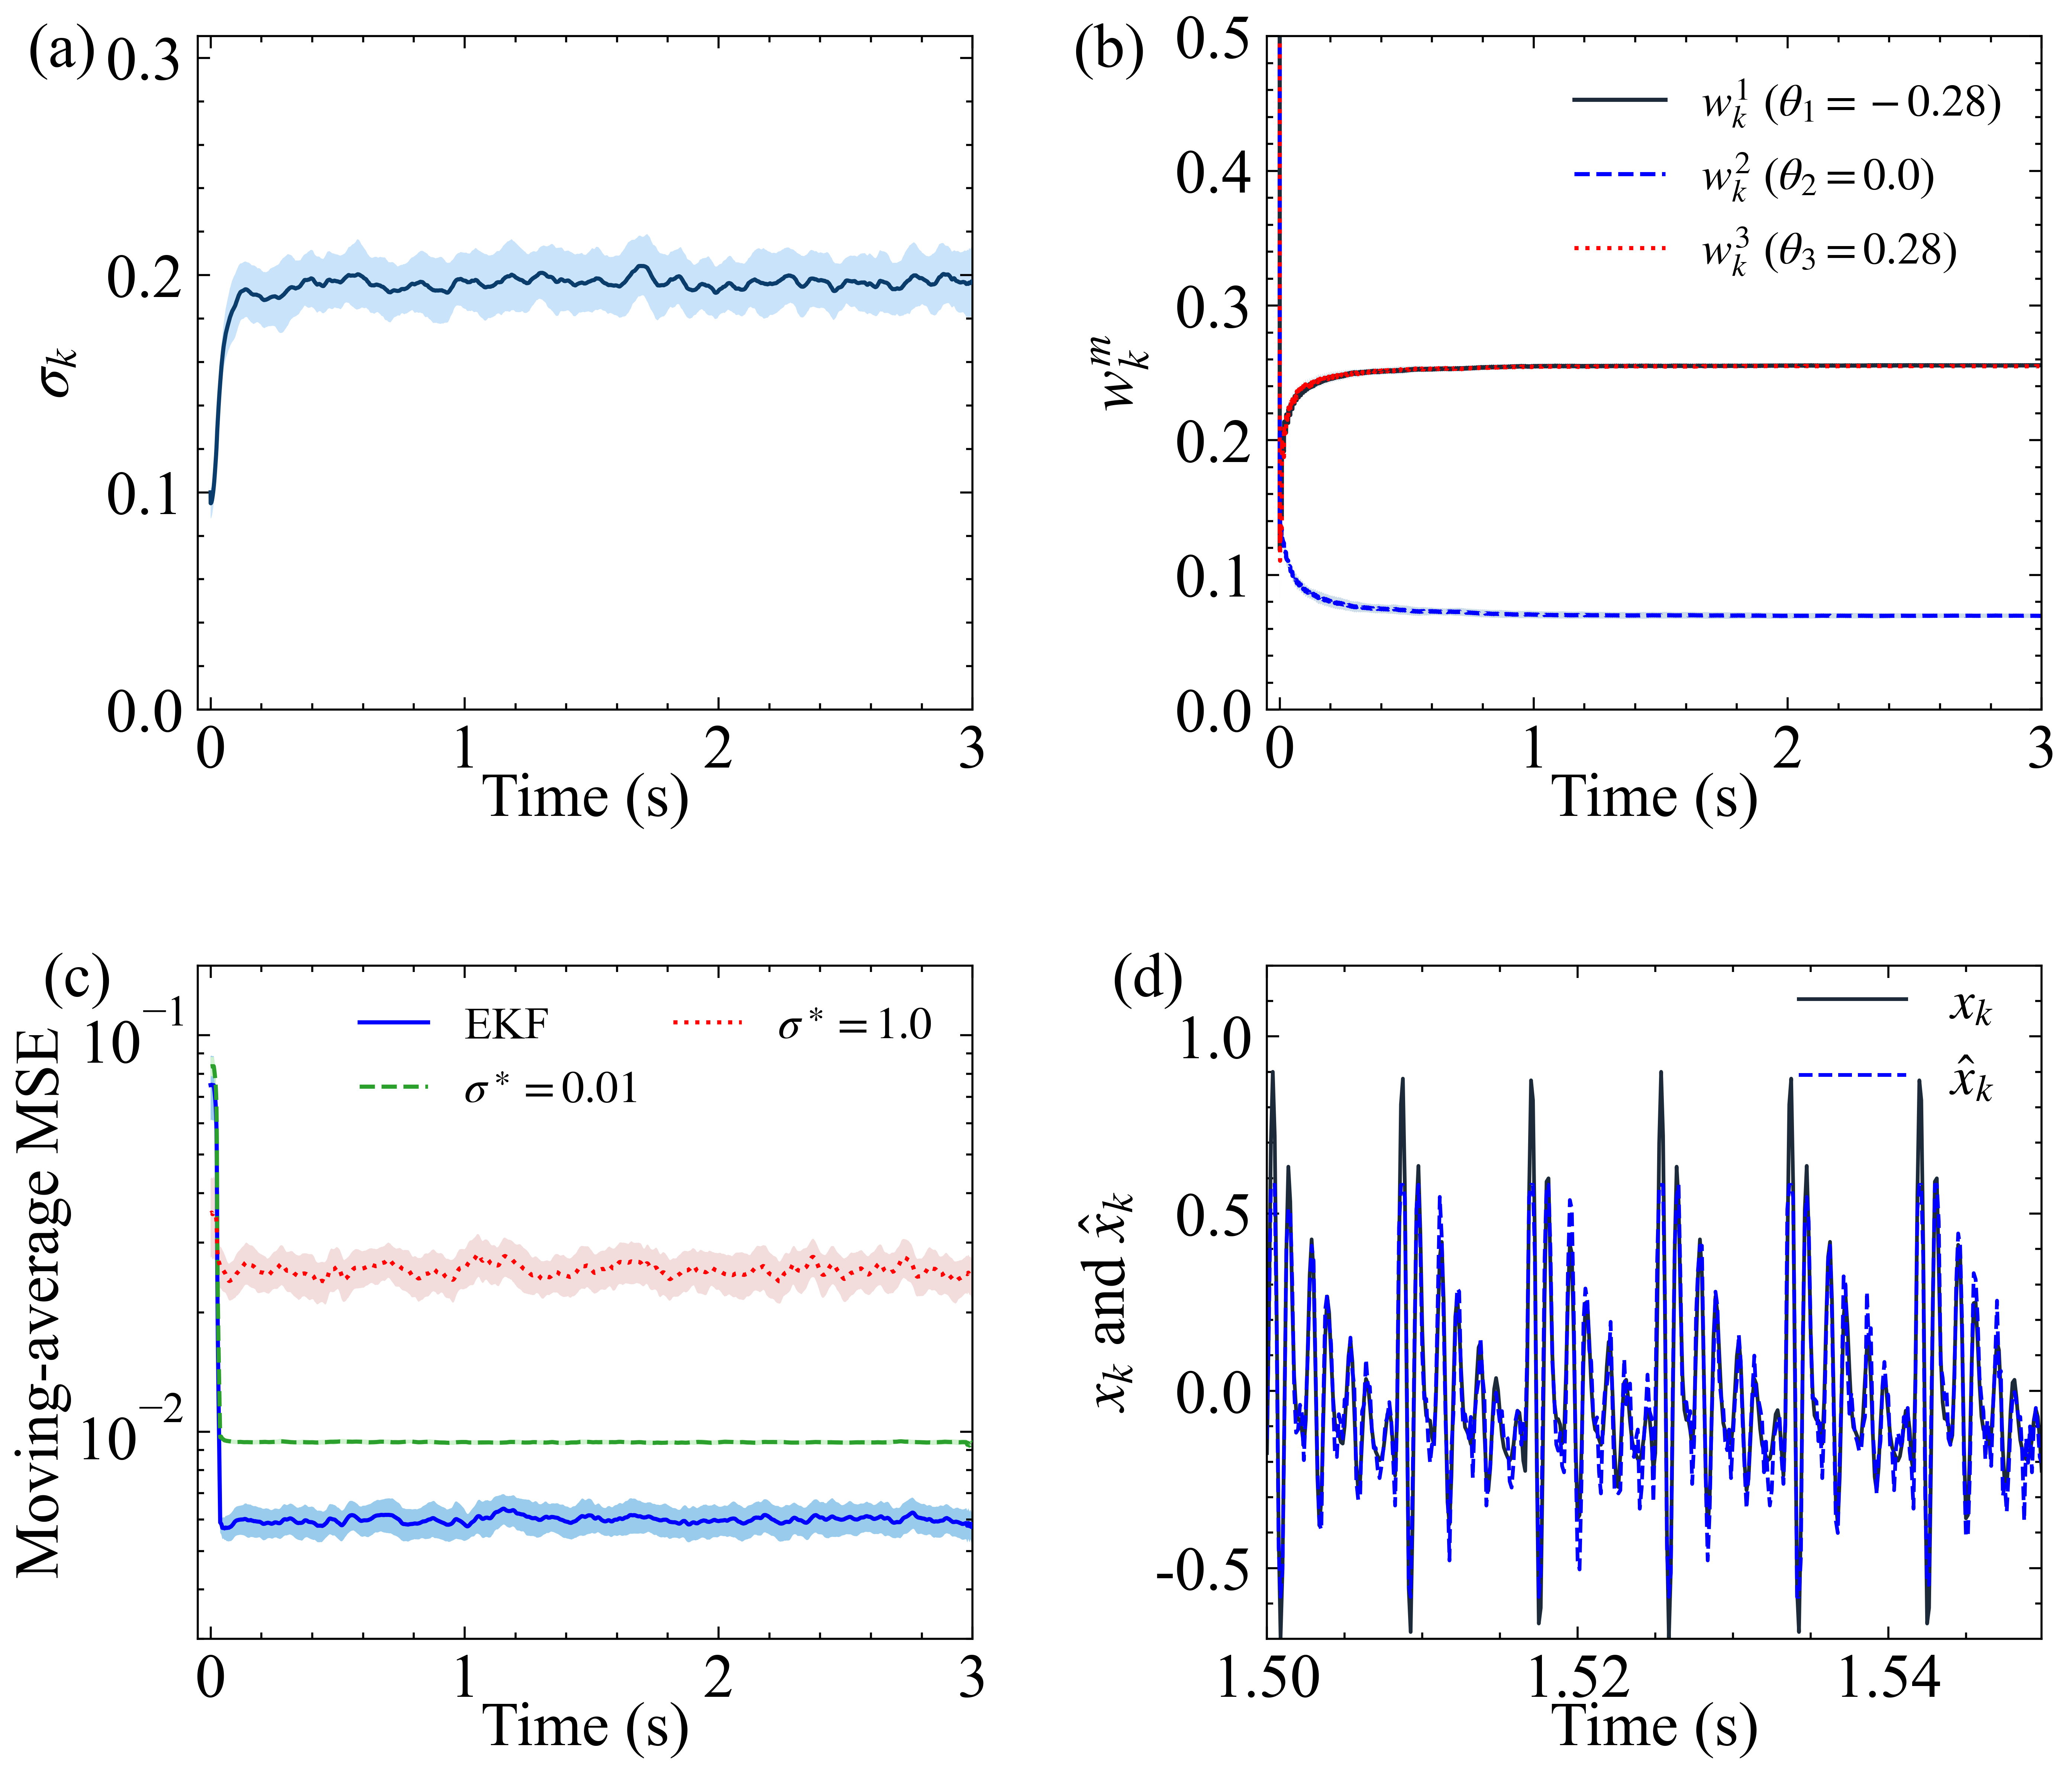

In [13]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import colorsys

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size'       : 15,
    'axes.labelsize'  : 15,
    'legend.fontsize' : 13,
})
mpl.rcParams['text.usetex'] = False

def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white.
    amount=0 returns white, amount=1 returns original color.
    EPS-compatible: no alpha needed.
    """
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount*(1-c[1]), c[2])

# ── 配色：深色画线，浅色填阴影，无需alpha ────────────
c_sigma  = '#0a3d6b'   # 深海军蓝，远比#1f77b4深
lc_sigma = lighten_color(c_sigma, amount=0.15)  # 极浅，接近白色
c_w1     = '#1c2a39';  lc_w1    = lighten_color(c_w1,    amount=0.22)
c_w2     = '#355c7d';  lc_w2    = lighten_color(c_w2,    amount=0.22)
c_w3     = '#6497b1';  lc_w3    = lighten_color(c_w3,    amount=0.22)
c_ekf    = '#1f77b4';  lc_ekf   = lighten_color(c_ekf,   amount=0.4)
c_fix    = '#2ca02c';  lc_fix   = lighten_color(c_fix,   amount=0.20)
c_sub    = '#c44e52';  lc_sub   = lighten_color(c_sub,   amount=0.20)
c_clean  = '#1c2a39'

labels_txt = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
plt.subplots_adjust(hspace=0.38, wspace=0.38)
axes = axes.flatten()
t_sec = t_arr

# ── (a) sigma_k ───────────────────────────────────────
# ── (a) sigma_k ───────────────────────────────────────
ax = axes[0]

from scipy.ndimage import uniform_filter1d
def smooth_after_transient(mean, std, cutoff, window):
    mean_s = mean.copy()
    std_s  = std.copy()
    mean_s[cutoff:] = uniform_filter1d(mean[cutoff:], size=window)
    std_s[cutoff:]  = uniform_filter1d(std[cutoff:],  size=window)
    return mean_s, std_s
# 对均值做滑动平均平滑，窗口对应约50ms
smooth_window = int(0.05 * fs)   # 400个点
sig_mean_s, sig_std_s = smooth_after_transient(
    sig_mean, sig_std, 0, smooth_window)  # cutoff=0，全部平滑

# 强行恢复起始点
sig_mean_s[0] = 0.1
sig_std_s[0]  = 0.0   # 起始点std为0，因为所有trial初值相同

ax.fill_between(t_sec,
                np.maximum(sig_mean_s - sig_std_s, 0),
                sig_mean_s + sig_std_s,
                color=lc_sigma, edgecolor='none')
ax.plot(t_sec, sig_mean_s, color=c_sigma, lw=1.0, zorder=5,)

ax.set_xlim([-0.05, duration])
ax.set_ylim([0, 0.31])
ax.set_yticks(np.arange(0, 0.35, 0.1))
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$\sigma_k$', labelpad=6)
ax.text(-0.22, 1.02, labels_txt[0], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (b) w1_k, w2_k, w3_k ─────────────────────────────
ax = axes[1]
ax.fill_between(t_sec,
                np.maximum(w1_mean - w1_std, 0),
                w1_mean + w1_std,
                color=lc_w1, edgecolor='none')
ax.plot(t_sec, w1_mean, color=c_w1, lw=1.0,
        label=rf'$w_k^1$ ($\theta_1={theta1}$)')

ax.fill_between(t_sec,
                np.maximum(w2_mean - w2_std, 0),
                w2_mean + w2_std,
                color=lc_w2, edgecolor='none')
ax.plot(t_sec, w2_mean, color='b', lw=1.0, ls='--',
        label=rf'$w_k^2$ ($\theta_2={theta2}$)')

ax.fill_between(t_sec,
                np.maximum(w3_mean - w3_std, 0),
                w3_mean + w3_std,
                color=lc_w3, edgecolor='none')
ax.plot(t_sec, w3_mean, color='r', lw=1.0, ls=':',
        label=rf'$w_k^3$ ($\theta_3={theta3}$)')

ax.set_xlim([-0.05, duration])
ax.set_ylim([0.0, 0.5])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$w_{k}^m$', labelpad=6)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.text(-0.25, 1.02, labels_txt[1], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (c) 滑动平均 MSE（log轴）─────────────────────────
ax = axes[2]
from scipy.ndimage import uniform_filter1d

# 对三条MSE曲线都做平滑
smooth_window = int(0.05 * fs)   # 400个点，与(a)图一致

mekf_mean_smooth = uniform_filter1d(mekf_mean, size=smooth_window)
mekf_std_smooth  = uniform_filter1d(mekf_std,  size=smooth_window)

mfix_mean_smooth = uniform_filter1d(mfix_mean, size=smooth_window)
mfix_std_smooth  = uniform_filter1d(mfix_std,  size=smooth_window)

msub_mean_smooth = uniform_filter1d(msub_mean, size=smooth_window)
msub_std_smooth  = uniform_filter1d(msub_std,  size=smooth_window)

# ── (c) 滑动平均 MSE（log轴）─────────────────────────
ax = axes[2]
ax.fill_between(t_sec,
                np.maximum(mekf_mean_smooth - mekf_std_smooth, 1e-5),
                mekf_mean_smooth + mekf_std_smooth,
                color=lc_ekf, edgecolor='none')
ax.plot(t_sec, mekf_mean_smooth,
        color='b', lw=1.0, zorder=5, label='EKF')

ax.fill_between(t_sec,
                np.maximum(mfix_mean_smooth - mfix_std_smooth, 1e-5),
                mfix_mean_smooth + mfix_std_smooth,
                color=lc_fix, edgecolor='none')
ax.plot(t_sec, mfix_mean_smooth,
        color=c_fix, lw=1.0, zorder=5, ls='--',
        label=rf'$\sigma^\ast = {sigma_fixed}$')

ax.fill_between(t_sec,
                np.maximum(msub_mean_smooth - msub_std_smooth, 1e-5),
                msub_mean_smooth + msub_std_smooth,
                color=lc_sub, edgecolor='none')
ax.plot(t_sec, msub_mean_smooth,
        color='r', lw=1.0, zorder=5, ls=':',
        label=r'$\sigma^\ast = 1.0$')

ax.set_yscale('log')
ax.set_xlim([-0.05, duration])
ax.set_ylim([3e-3, 1.5e-1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'Moving-average MSE', labelpad=1)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9,
          ncol=2, columnspacing=0.8, handlelength=1.5)
ax.text(-0.2, 1.02, labels_txt[2], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (d) 50 ms 波形重建 ────────────────────────────────
ax = axes[3]
k0     = steady
k1     = k0 + int(0.05 * fs)
t_show = t_sec[k0:k1]
ax.plot(t_show, speech[k0:k1],
        color=c_clean, lw=0.9, label=r'$x_k$')
ax.plot(t_show, xhat_ekf_demo[k0:k1],
        color='blue', lw=0.9, ls='--', label=r'$\hat{x}_k$')
ax.set_ylim([-0.7, 1.2])
ax.set_xlim([t_show[0], t_show[-1]])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$', labelpad=4)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.05),
          fontsize=13, framealpha=0.9)
ax.text(-0.2, 1.02, labels_txt[3], transform=ax.transAxes,
        fontsize=15, va='top')

fig.savefig('D:/IEEE 2025 Adaptive weighted SSR/Figspeech.eps',
            format='eps', dpi=800, bbox_inches='tight')
plt.show()

In [5]:
np.savez('D:/IEEE 2025 Adaptive weighted SSR/speech_3group_results.npz',
         # 信号本身
         speech       = speech,
         t_arr        = t_arr,
         # Monte Carlo 原始数据
         all_sig      = all_sig,
         all_w1       = all_w1,
         all_w2       = all_w2,
         all_w3       = all_w3,
         all_mekf     = all_mekf,
         all_mfix     = all_mfix,
         all_msub     = all_msub,
         # 均值和标准差
         sig_mean     = sig_mean,   sig_std  = sig_std,
         w1_mean      = w1_mean,    w1_std   = w1_std,
         w2_mean      = w2_mean,    w2_std   = w2_std,
         w3_mean      = w3_mean,    w3_std   = w3_std,
         mekf_mean    = mekf_mean,  mekf_std = mekf_std,
         mfix_mean    = mfix_mean,  mfix_std = mfix_std,
         msub_mean    = msub_mean,  msub_std = msub_std,
         # 第一个trial的重建波形
         xhat_ekf_demo = xhat_ekf_demo,
         # 稳态标量
         sig_ss       = np.array([sig_ss]),
         w1_ss        = np.array([w1_ss]),
         w2_ss        = np.array([w2_ss]),
         w3_ss        = np.array([w3_ss]),
         mse_ekf_ss   = np.array([mse_ekf_ss]),
         mse_fix_ss   = np.array([mse_fix_ss]),
         mse_sub_ss   = np.array([mse_sub_ss]),
)
print("Data saved to speech_3group_results.npz")

Data saved to speech_3group_results.npz


In [1]:
import numpy as np

# 读入数据
data = np.load('D:/IEEE 2025 Adaptive weighted SSR/speech_3group_results.npz')

# 信号本身
speech        = data['speech']
t_arr         = data['t_arr']

# Monte Carlo 原始数据
all_sig       = data['all_sig']
all_w1        = data['all_w1']
all_w2        = data['all_w2']
all_w3        = data['all_w3']
all_mekf      = data['all_mekf']
all_mfix      = data['all_mfix']
all_msub      = data['all_msub']

# 均值和标准差
sig_mean      = data['sig_mean'];    sig_std  = data['sig_std']
w1_mean       = data['w1_mean'];     w1_std   = data['w1_std']
w2_mean       = data['w2_mean'];     w2_std   = data['w2_std']
w3_mean       = data['w3_mean'];     w3_std   = data['w3_std']
mekf_mean     = data['mekf_mean'];   mekf_std = data['mekf_std']
mfix_mean     = data['mfix_mean'];   mfix_std = data['mfix_std']
msub_mean     = data['msub_mean'];   msub_std = data['msub_std']

# 第一个trial的重建波形
xhat_ekf_demo = data['xhat_ekf_demo']

# 稳态标量（保存时是array，读回来要取[0]）
sig_ss        = float(data['sig_ss'])
w1_ss         = float(data['w1_ss'])
w2_ss         = float(data['w2_ss'])
w3_ss         = float(data['w3_ss'])
mse_ekf_ss    = float(data['mse_ekf_ss'])
mse_fix_ss    = float(data['mse_fix_ss'])
mse_sub_ss    = float(data['mse_sub_ss'])

# 恢复信号参数
fs            = 8000
duration      = 3.0
Nx_total      = len(t_arr)
steady        = Nx_total // 2
sigma_fixed   = 0.5      # 与保存时一致

# 恢复阵列参数
N1, theta1    = 10, -0.25
N2, theta2    = 11,  0.00
N3, theta3    = 10, +0.25

print("Data loaded successfully.")
print(f"  Nx_total={Nx_total}, num_trials={all_sig.shape[0]}")
print(f"  sig_ss={sig_ss:.4f}, w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

Data loaded successfully.
  Nx_total=24000, num_trials=20
  sig_ss=0.2849, w1=0.2045, w2=0.1500, w3=0.1973


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18444\2968595549.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sig_ss        = float(data['sig_ss'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_18444\2968595549.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w1_ss         = float(data['w1_ss'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_18444\2968595549.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w2_ss         = float(data['

In [5]:
for sig_test in [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]:
    mse_t, _ = run_grouped_fixed(speech, sig_test, seed=451)
    ss = causal_ma(mse_t, 100)[steady:].mean()
    snr_t = 10*np.log10(np.mean(speech[steady:]**2) / ss)
    print(f"sigma={sig_test:.3f}: MSE={ss:.5f}, SNR={snr_t:.2f} dB")

sigma=0.001: MSE=0.01027, SNR=8.90 dB
sigma=0.010: MSE=0.00942, SNR=9.28 dB
sigma=0.050: MSE=0.00647, SNR=10.91 dB
sigma=0.100: MSE=0.00530, SNR=11.78 dB
sigma=0.200: MSE=0.00602, SNR=11.22 dB
sigma=0.300: MSE=0.00750, SNR=10.27 dB
sigma=0.500: MSE=0.01094, SNR=8.63 dB
sigma=1.000: MSE=0.02596, SNR=4.87 dB


In [14]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import gaussian_kde
#import scienceplots

# ════════════════════════════════════════════════════════
# 1.  合成语音信号（元音 /a/，男声 F0=120 Hz）
# ════════════════════════════════════════════════════════
torch.manual_seed(2024)
np.random.seed(2024)

fs       = 8000
duration = 3.0
t_arr    = np.arange(0, duration, 1/fs)
Nx_total = len(t_arr)

F0 = 120;  harmonics = 25
voice_src = np.zeros(Nx_total)
for k in range(1, harmonics+1):
    voice_src += (1.0/k) * np.sin(2*np.pi*k*F0*t_arr)

def formant_filter(sig, fc, bw):
    r     = np.exp(-np.pi*bw/fs)
    theta = 2*np.pi*fc/fs
    return lfilter([1-r], [1, -2*r*np.cos(theta), r**2], sig)

speech = formant_filter(voice_src, 800,  80)
speech = formant_filter(speech,    1200, 100)
speech = formant_filter(speech,    2500, 150)

# 幅值调制：模拟音节强度的自然起伏
# 5Hz调制 ≈ 每200ms一个音节，符合正常语速
modulation = 0.5 + 0.5 * np.sin(2*np.pi*5*t_arr)
speech = speech * modulation

speech = speech / np.max(np.abs(speech)) * 0.9

sigma_x = float(np.std(speech))
kurt    = float(np.mean((speech - speech.mean())**4) / sigma_x**4 - 3)
print(f"Speech: {Nx_total} samples, fs={fs} Hz")
print(f"  sigma_x={sigma_x:.4f}, excess kurtosis={kurt:.2f} "
      f"(Gaussian=0, Laplace≈3)")

# ════════════════════════════════════════════════════════
# 2.  三组阵列参数
# ════════════════════════════════════════════════════════
N1, theta1 = 15, -0.28
N2, theta2 = 15,  0.00
N3, theta3 = 15, +0.28
N_total    = N1 + N2 + N3      # = 45

print(f"\nArray configuration (N_total={N_total}):")
print(f"  Group 1: N1={N1}, theta1={theta1}")
print(f"  Group 2: N2={N2}, theta2={theta2}")
print(f"  Group 3: N3={N3}, theta3={theta3}")

# ════════════════════════════════════════════════════════
# 3.  三组 EKF-SSR（PyTorch）
# ════════════════════════════════════════════════════════
Q_sigma   = 1e-3
R_sigma   = 1.0
P0_sigma  = 2.0
delta_rls = 0.1
window    = 100

def gauss_pdf_t(u):
    return torch.exp(-0.5*u**2) / (2*torch.pi)**0.5

def run_grouped_ekf_ssr(x_np, sigma_init, seed=2024):
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))

    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0

    sigma_k = torch.tensor(float(sigma_init))
    P_sigma = torch.tensor(float(P0_sigma))

    sigma_hist = np.zeros(T)
    w1_hist    = np.zeros(T)
    w2_hist    = np.zeros(T)
    w3_hist    = np.zeros(T)
    mse_inst   = np.zeros(T)
    xhat_hist  = np.zeros(T)

    for k in range(T):
        x_k = x_t[k]

        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sigma_k*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sigma_k*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sigma_k*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])

        x_hat = torch.dot(w, phi_k)
        e_k   = x_k - x_hat

        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g_rls = P_phi / denom
        w     = w + g_rls * e_k
        P_w   = P_w - torch.outer(g_rls, P_phi)

        s_safe = sigma_k.clamp(min=0.01)
        u1 = (x_k - th1) / s_safe
        u2 = (x_k - th2) / s_safe
        u3 = (x_k - th3) / s_safe
        dh1 = -2*(x_k - th1) / s_safe**2 * gauss_pdf_t(u1)
        dh2 = -2*(x_k - th2) / s_safe**2 * gauss_pdf_t(u2)
        dh3 = -2*(x_k - th3) / s_safe**2 * gauss_pdf_t(u3)
        H_k = w[0]*dh1 + w[1]*dh2 + w[2]*dh3

        P_pred  = P_sigma + Q_sigma
        K_sigma = P_pred * H_k / (H_k**2 * P_pred + R_sigma)
        step    = (K_sigma * e_k).clamp(-0.3, 0.3)
        sigma_k = (sigma_k + step).clamp(0.01, 5.0)
        P_sigma = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_k.item()
        w1_hist[k]    = w[0].item()
        w2_hist[k]    = w[1].item()
        w3_hist[k]    = w[2].item()
        mse_inst[k]   = e_k.item()**2
        xhat_hist[k]  = x_hat.item()

    return sigma_hist, w1_hist, w2_hist, w3_hist, mse_inst, xhat_hist


def run_grouped_fixed(x_np, sigma_fixed, seed=2024):
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)
    th1 = torch.tensor(float(theta1))
    th2 = torch.tensor(float(theta2))
    th3 = torch.tensor(float(theta3))
    w   = torch.tensor([1.0, 1.0, 1.0])
    P_w = torch.eye(3) * 10.0
    sf  = torch.tensor(float(sigma_fixed))
    mse_inst  = np.zeros(T)
    xhat_hist = np.zeros(T)
    for k in range(T):
        x_k = x_t[k]
        torch.manual_seed(seed + 3*k)
        phi1 = torch.sign(x_k + sf*torch.randn(N1) - th1).mean()
        torch.manual_seed(seed + 3*k + 1)
        phi2 = torch.sign(x_k + sf*torch.randn(N2) - th2).mean()
        torch.manual_seed(seed + 3*k + 2)
        phi3 = torch.sign(x_k + sf*torch.randn(N3) - th3).mean()
        phi_k = torch.stack([phi1, phi2, phi3])
        x_hat = torch.dot(w, phi_k); e_k = x_k - x_hat
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g     = P_phi / denom
        w     = w + g*e_k
        P_w   = P_w - torch.outer(g, P_phi)
        mse_inst[k]  = e_k.item()**2
        xhat_hist[k] = x_hat.item()
    return mse_inst, xhat_hist

def causal_ma(x, win):
    out = np.zeros(len(x))
    cs  = np.cumsum(x)
    for i in range(len(x)):
        out[i] = cs[i]/(i+1) if i < win else (cs[i]-cs[i-win])/win
    return out

# ════════════════════════════════════════════════════════
# 4.  Monte Carlo
# ════════════════════════════════════════════════════════
num_trials    = 20
base_seed     = 451
steady        = Nx_total // 2
sigma_fixed   = 0.01   # fixed suboptimal sigma for comparison

all_sig  = np.zeros((num_trials, Nx_total))
all_w1   = np.zeros((num_trials, Nx_total))
all_w2   = np.zeros((num_trials, Nx_total))
all_w3   = np.zeros((num_trials, Nx_total))
all_mekf = np.zeros((num_trials, Nx_total))
all_mfix = np.zeros((num_trials, Nx_total))
all_msub = np.zeros((num_trials, Nx_total))
xhat_ekf_demo = None

print(f"\nRunning {num_trials} Monte Carlo trials...")
for tr in range(num_trials):
    seed_t = base_seed + tr * 17
    if tr % 5 == 0:
        print(f"  trial {tr+1}/{num_trials}")

    sh, w1h, w2h, w3h, mse_e, xhat_e = run_grouped_ekf_ssr(
        speech, sigma_init=0.1, seed=seed_t)
    all_sig[tr]  = sh
    all_w1[tr]   = w1h
    all_w2[tr]   = w2h
    all_w3[tr]   = w3h
    all_mekf[tr] = causal_ma(mse_e, window)
    if tr == 0:
        xhat_ekf_demo = xhat_e

    mse_f, _ = run_grouped_fixed(speech, sigma_fixed, seed=seed_t)
    all_mfix[tr] = causal_ma(mse_f, window)

    mse_s, _ = run_grouped_fixed(speech, 1.0, seed=seed_t)
    all_msub[tr] = causal_ma(mse_s, window)

sig_mean  = all_sig.mean(0);   sig_std  = all_sig.std(0)
w1_mean   = all_w1.mean(0);    w1_std   = all_w1.std(0)
w2_mean   = all_w2.mean(0);    w2_std   = all_w2.std(0)
w3_mean   = all_w3.mean(0);    w3_std   = all_w3.std(0)
mekf_mean = all_mekf.mean(0);  mekf_std = all_mekf.std(0)
mfix_mean = all_mfix.mean(0);  mfix_std = all_mfix.std(0)
msub_mean = all_msub.mean(0);  msub_std = all_msub.std(0)

sp_pwr     = np.mean(speech[steady:]**2)
mse_ekf_ss = all_mekf[:, steady:].mean()
mse_fix_ss = all_mfix[:, steady:].mean()
mse_sub_ss = all_msub[:, steady:].mean()
sig_ss     = all_sig[:,  steady:].mean()
w1_ss      = all_w1[:,   steady:].mean()
w2_ss      = all_w2[:,   steady:].mean()
w3_ss      = all_w3[:,   steady:].mean()
snr_ekf    = 10*np.log10(sp_pwr / mse_ekf_ss)
snr_fix    = 10*np.log10(sp_pwr / mse_fix_ss)
snr_sub    = 10*np.log10(sp_pwr / mse_sub_ss)

print(f"\n{'Method':<40} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*70)
for name, sig, mse, snr in [
    ("Grouped EKF-SSR (proposed)",        sig_ss,       mse_ekf_ss, snr_ekf),
    (f"Grouped fixed sigma={sigma_fixed}", sigma_fixed,  mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",            1.0,          mse_sub_ss, snr_sub),
]:
    print(f"{name:<40} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print(f"\nEKF-SSR vs fixed {sigma_fixed}  : +{snr_ekf-snr_fix:.2f} dB")
print(f"EKF-SSR vs fixed 1.0 : +{snr_ekf-snr_sub:.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

# ════════════════════════════════════════════════════════
# 6.  稳态汇总表
# ════════════════════════════════════════════════════════
print("\n" + "="*70)
print(f"3-Group SSR  N1={N1},θ1={theta1} | N2={N2},θ2={theta2} "
      f"| N3={N3},θ3={theta3}")
print(f"{num_trials} trials, speech /a/, fs={fs} Hz")
print("="*70)
print(f"{'Method':<40} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*70)
for name, sig, mse, snr in [
    ("Grouped EKF-SSR (proposed)",        sig_ss,      mse_ekf_ss, snr_ekf),
    (f"Grouped fixed sigma={sigma_fixed}", sigma_fixed, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",            1.0,         mse_sub_ss, snr_sub),
]:
    print(f"{name:<40} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print("="*70)
print(f"SNR gain (EKF vs fixed {sigma_fixed}) : +{snr_ekf-snr_fix:.2f} dB")
print(f"SNR gain (EKF vs fixed 1.0)  : +{snr_ekf-snr_sub:.2f} dB")
print(f"Steady weights: w1={w1_ss:.4f}, w2={w2_ss:.4f}, w3={w3_ss:.4f}")

Speech: 24000 samples, fs=8000 Hz
  sigma_x=0.1728, excess kurtosis=5.68 (Gaussian=0, Laplace≈3)

Array configuration (N_total=45):
  Group 1: N1=15, theta1=-0.28
  Group 2: N2=15, theta2=0.0
  Group 3: N3=15, theta3=0.28

Running 20 Monte Carlo trials...
  trial 1/20
  trial 6/20
  trial 11/20
  trial 16/20

Method                                     sigma        MSE  SNR(dB)
----------------------------------------------------------------------
Grouped EKF-SSR (proposed)                0.1781    0.00295     9.81
Grouped fixed sigma=0.01                  0.0100    0.00469     7.79
Grouped fixed sigma=1.0                   1.0000    0.01610     2.44

EKF-SSR vs fixed 0.01  : +2.02 dB
EKF-SSR vs fixed 1.0 : +7.38 dB
Steady weights: w1=0.2138, w2=0.0852, w3=0.2160

3-Group SSR  N1=15,θ1=-0.28 | N2=15,θ2=0.0 | N3=15,θ3=0.28
20 trials, speech /a/, fs=8000 Hz
Method                                     sigma        MSE  SNR(dB)
----------------------------------------------------------------